# PEMS-PINN de CO — evaluación interpolativa final

**Versión:** R5F_STD  
**Estado:** FINAL; consume exclusivamente contratos `FROZEN` de PROTOCOL R1 y OPT R5  
**Propósito:** entrenar una única PINN definitiva con todo DEV, congelarla antes de acceder a TEST y realizar una sola evaluación externa sin reajustes posteriores.  
**Objetivo:** CO, en mg/m³  
**Física activa:** `CDP_NEG`, es decir, $\partial \widehat{CO}/\partial CDP\leq0$  
**Entorno previsto:** Google Colab o ejecución local desde la raíz canónica del proyecto.  
**Entradas:** asignación interpolativa R1, configuración ganadora, política final de épocas, seed representativa y manifiesto FROZEN de CO OPT R5.  
**Salidas:** modelo serializado, predicciones DEV/TEST, métricas predictivas y físicas, ocho figuras, perfil computacional, hashes y reporte técnico.

## Mapa del notebook

| Sección | Finalidad |
|---|---|
| SEC-01 | entorno, rutas y reproducibilidad |
| SEC-02 | verificación integral del handoff `FROZEN` |
| SEC-03 | materialización autorizada de DEV; TEST cerrado |
| SEC-04 | arquitectura, transformación y física `CDP_NEG` |
| SEC-05 | controles previos al entrenamiento |
| SEC-06 | entrenamiento del modelo único y congelamiento |
| SEC-07 | puerta irreversible y apertura única de TEST |
| SEC-08 | evaluación predictiva y física sin selección post hoc |
| SEC-09 | figuras y perfil computacional |
| SEC-10 | persistencia, manifiesto, hashes y cierre |

### Contrato científico

1. El FINAL no ejecuta Optuna ni compara configuraciones, seeds o modos físicos.
2. `FINAL_EPOCHS`, `FINAL_REPRESENTATIVE_SEED` y `USE_LBFGS` proceden del handoff R5.
3. Los escaladores y el soporte físico se ajustan únicamente con DEV completo.
4. El modelo se serializa y se recarga de forma equivalente antes de leer `y_TEST`.
5. TEST se abre una sola vez; sus resultados no autorizan reentrenamiento ni sustitución.
6. Un `PCD_TEST < 95 %` se registra como `TEST_PHYSICS_GATE_FAIL`; no cambia el modelo.

> **Ajuste frente a plantillas multisemilla:** el manifiesto R5 contiene las cinco seeds de confirmación, pero el handoff congela la seed 126 como representante final. Este notebook entrena un solo modelo y no crea un ensamble.


## SEC-01 — Entorno y configuración de ejecución

### C-01.01 — Acceso a Drive y dependencias

**Objetivo:** resolver una raíz canónica y asegurar dependencias mínimas.  
**Entradas:** variable opcional `TURBINE_EMISSIONS_PINN_ROOT`.  
**Salida:** `PROJECT_ROOT_PATH`.  
**Fallo:** raíz inexistente o paquetes obligatorios no instalables.


In [1]:
# [C-01.01] Acceso a Drive, raíz y dependencias
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

REQUIRED_PACKAGES = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "psutil": "psutil",
    "sklearn": "scikit-learn",
    "torch": "torch",
}
missing_packages = [
    package
    for module, package in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )

GOOGLE_NAMESPACE_AVAILABLE = importlib.util.find_spec("google") is not None
IN_COLAB = (
    GOOGLE_NAMESPACE_AVAILABLE
    and importlib.util.find_spec("google.colab") is not None
)
if IN_COLAB:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")

default_root = (
    Path("/content/drive/MyDrive/Turbine_Emissions_PINN")
    if IN_COLAB
    else (
        Path.cwd().parent
        if Path.cwd().name.lower() == "notebooks"
        else Path.cwd()
    )
)
PROJECT_ROOT_PATH = os.environ.get(
    "TURBINE_EMISSIONS_PINN_ROOT",
    str(default_root),
)

print(
    {
        "entorno": "Google Colab" if IN_COLAB else "local",
        "raíz_configurada": PROJECT_ROOT_PATH,
        "paquetes_instalados": missing_packages,
    }
)


{'entorno': 'local', 'raíz_configurada': 'C:\\ChatGPT-Work\\Walk_Forward R8', 'paquetes_instalados': []}


### C-01.02 — Constantes científicas y contrato de rutas

**Objetivo:** declarar solo constantes de ejecución; las decisiones del modelo se leerán de OPT R5.  
**Control:** `TARGET`, física y consumidor deben coincidir con el manifiesto FROZEN.


In [2]:
# [C-01.02] Constantes científicas y contrato de rutas
import contextlib
import copy
import hashlib
import importlib.metadata
import json
import math
import os
import platform
import random
import shutil
import tempfile
import time
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

VERSION = "CO_INTERP_FINAL_R5F_STD"
PROTOCOL_VERSION = "INTERP_PROTOCOL_R1"
OPT_VERSION = "CO_INTERP_OPT_R5"
EXPECTED_CAMPAIGN_SCHEMA = "R5_AUTONOMOUS_TPE_CDP_NEG_2PLUS3_TOP10_LBFGS"
EXPECTED_STOP_POLICY = {
    "stop_policy_version": "R5_TOP10_STABILIZATION_V1",
    "minimum_attempted_trials": 100,
    "minimum_complete_total_trials": 50,
    "material_gain": 0.002,
    "adaptive_block_size": 10,
    "stable_blocks_required": 3,
    "maximum_attempted_trials": 200,
}
PROTOCOL_NOTEBOOK_NAME = "00_PEMS_PINN_INTERP_PROTOCOL - R1.ipynb"
OPT_NOTEBOOK_NAME = "04_Gold_Standard_PINN_CO_INTERP_OPT - R5.ipynb"
CURRENT_NOTEBOOK_NAME = "04_Gold_Standard_PINN_CO_INTERP_FINAL - R5F_STD.ipynb"

FEATURES = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "TEY", "CDP"]
TARGET = "CO"
PHYSICS_MODE = "CDP_NEG"
PHYSICS_FEATURE = "CDP"
EXPECTED_DERIVATIVE_SIGN = "<= 0"
MONOTONIC_CONSTRAINT = "dCO_dCDP_le_0"
PHYSICS_SCALE_QUANTILES = (0.05, 0.95)
PCD_REFERENCE_THRESHOLD_PCT = 95.0
YEARS = [2011, 2012, 2013, 2014, 2015]
PHYSICS_EVAL_ROWS = 2048
EPS_DIMENSIONLESS = 1e-6
MAX_TRAINABLE_PARAMETERS = 500_000
LATENCY_WARMUP = 20
LATENCY_REPETITIONS = 200
THROUGHPUT_WARMUP = 5
THROUGHPUT_REPETITIONS = 30
PDP_POINTS = 120
TF32 = True

PROTOCOL_REL = Path("models") / "interp" / "work_pinn_interp_protocol"
OPT_REL = Path("models") / "interp" / "work_pinn_co_interp_opt_r5"
OUTPUT_REL = Path("models") / "interp" / "work_pinn_co_interp_final_r5f_std"


@dataclass(frozen=True)
class FinalPaths:
    """Rutas persistentes del entregable FINAL."""

    root: Path
    work: Path
    audit: Path
    configs: Path
    tables: Path
    figures: Path
    model: Path
    reports: Path


def make_paths(root: Path) -> FinalPaths:
    """Crea únicamente la estructura canónica de salida FINAL."""
    work = root / OUTPUT_REL
    paths = FinalPaths(
        root=root,
        work=work,
        audit=work / "audit",
        configs=work / "configs",
        tables=work / "tables",
        figures=work / "figures",
        model=work / "model",
        reports=work / "reports",
    )
    for key, value in asdict(paths).items():
        if key != "root":
            Path(value).mkdir(parents=True, exist_ok=True)
    return paths


### C-01.03 — Utilidades reproducibles y entorno computacional

**Objetivo:** proveer hashing, escritura atómica, seeds y reporte de hardware.  
**Salida:** funciones puras y manifiesto de entorno.


In [3]:
# [C-01.03] Utilidades reproducibles y entorno computacional
def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()


def canonical_json(value: Any) -> str:
    return json.dumps(
        value,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
        default=str,
    )


def sha256_bytes(value: bytes) -> str:
    return hashlib.sha256(value).hexdigest()


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def config_hash(config: dict) -> str:
    payload = {key: value for key, value in config.items() if key != "config_hash"}
    return sha256_bytes(canonical_json(payload).encode("utf-8"))


def atomic_text(path: Path, text: str) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    descriptor, temporary_name = tempfile.mkstemp(
        prefix=path.name + ".",
        suffix=".tmp",
        dir=path.parent,
    )
    os.close(descriptor)
    temporary_path = Path(temporary_name)
    try:
        temporary_path.write_text(text, encoding="utf-8", newline="\n")
        os.replace(temporary_path, path)
    finally:
        if temporary_path.exists():
            temporary_path.unlink()


def atomic_json(path: Path, value: Any) -> None:
    atomic_text(
        path,
        json.dumps(value, ensure_ascii=False, indent=2, allow_nan=False, default=str)
        + "\n",
    )


def atomic_csv(path: Path, frame: pd.DataFrame) -> None:
    atomic_text(path, frame.to_csv(index=False, lineterminator="\n"))


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except RuntimeError:
        pass


def select_device() -> torch.device:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type == "cuda":
        torch.backends.cuda.matmul.allow_tf32 = TF32
        torch.backends.cudnn.allow_tf32 = TF32
    return device


def environment_manifest(device: torch.device) -> dict:
    return {
        "generated_at_utc": utc_now(),
        "python": sys.version,
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "sklearn": importlib.metadata.version("scikit-learn"),
        "torch": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "device": str(device),
        "gpu_name": (
            torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
        ),
        "logical_cpu_count": psutil.cpu_count(logical=True),
        "ram_gib": round(psutil.virtual_memory().total / 2**30, 3),
        "tf32": TF32,
        "deterministic_algorithms": "warn_only",
    }


### C-01.04 — Inicialización controlada

**Objetivo:** validar la raíz sin buscar copias alternativas.  
**Fallo:** ausencia de PROTOCOL R1, OPT R5 o sus notebooks productores.


In [4]:
# [C-01.04] Inicialización controlada
def validate_project_root(project_root_path: str | Path) -> Path:
    """Valida la estructura canónica sin seleccionar copias alternativas."""
    root = Path(project_root_path).expanduser()
    if not root.is_absolute():
        raise ValueError("PROJECT_ROOT_PATH debe ser una ruta absoluta")
    root = root.resolve()
    required = [
        root / "notebooks" / PROTOCOL_NOTEBOOK_NAME,
        root / "notebooks" / OPT_NOTEBOOK_NAME,
        root / PROTOCOL_REL,
        root / OPT_REL,
    ]
    missing = [str(path) for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "La raíz configurada no contiene la estructura requerida:\n- "
            + "\n- ".join(missing)
        )
    return root


PROJECT_ROOT = validate_project_root(PROJECT_ROOT_PATH)
PATHS = make_paths(PROJECT_ROOT)
DEVICE = select_device()
ENVIRONMENT = environment_manifest(DEVICE)
atomic_json(PATHS.audit / "ENVIRONMENT_CO_INTERP_FINAL_R5F_STD.json", ENVIRONMENT)

display(
    pd.Series(
        {
            "versión": VERSION,
            "dispositivo": str(DEVICE),
            "raíz": str(PROJECT_ROOT),
            "entrada PROTOCOL": str(PROJECT_ROOT / PROTOCOL_REL),
            "entrada OPT": str(PROJECT_ROOT / OPT_REL),
            "salida FINAL": str(PATHS.work),
            "política del modelo": "SINGLE_MODEL_FROM_REPRESENTATIVE_SEED",
        },
        name="valor",
    ).to_frame()
)


,valor
versión,CO_INTERP_FINAL_R5F_STD
dispositivo,cuda
raíz,C:\ChatGPT-Work\Walk_Forward R8
entrada PROTOCOL,C:\ChatGPT-Work\Walk_Forward R8\models\interp\...
entrada OPT,C:\ChatGPT-Work\Walk_Forward R8\models\interp\...
salida FINAL,C:\ChatGPT-Work\Walk_Forward R8\models\interp\...
política del modelo,SINGLE_MODEL_FROM_REPRESENTATIVE_SEED


## SEC-02 — Verificación cruzada de entradas `FROZEN`

### C-02.01 — Protocolo, campaña, configuración, seed y hashes

**Objetivo:** demostrar que todas las decisiones provienen de DEV y coinciden entre sus fuentes canónicas.  
**Entradas:** manifiestos R1, estado OPT R5, `BEST_CONFIG`, política final, seed representativa y handoff.  
**Salidas:** `FROZEN`, auditoría de hashes y contrato upstream.  
**Fallo:** cualquier hash distinto, estado no FROZEN, acceso previo a TEST o contradicción científica.

#### CHK-01 — Prohibición de reconstrucción silenciosa

Si falta una entrada o una firma no coincide, la ejecución se detiene. El FINAL no infiere hiperparámetros ni reemplaza artefactos.


In [5]:
# [C-02.01] Verificación integral de protocolo y handoff R5
def read_json(path: Path) -> dict:
    return json.loads(Path(path).read_text(encoding="utf-8"))


def resolve_protocol_data_sources(root: Path, split: dict) -> dict[int, Path]:
    """Resuelve los cinco CSV solo desde el manifiesto PROTOCOL R1."""
    records = split.get("data_hashes", [])
    if len(records) != len(YEARS):
        raise RuntimeError("El protocolo no declara exactamente cinco fuentes")
    sources: dict[int, Path] = {}
    for record in records:
        year = int(record["year"])
        relative = Path(str(record["path"]).replace("\\", "/"))
        expected = Path("data") / "raw" / f"gt_{year}.csv"
        if year not in YEARS or year in sources or relative != expected:
            raise RuntimeError(f"Fuente no canónica o duplicada para {year}")
        path = (root / relative).resolve()
        if not path.is_file() or sha256_file(path) != record.get("sha256"):
            raise RuntimeError(f"Fuente ausente o hash distinto para {year}")
        sources[year] = path
    if set(sources) != set(YEARS):
        raise RuntimeError("Los años de PROTOCOL no coinciden con YEARS")
    return sources


def verify_r5_stop_policy(frozen_opt: dict, campaign_state: dict) -> dict:
    """Comprueba la política adaptativa realmente congelada por CO OPT R5."""
    observed = {
        "stop_policy_version": frozen_opt.get("stop_policy_version"),
        "minimum_attempted_trials": frozen_opt.get("minimum_attempted_trials"),
        "minimum_complete_total_trials": frozen_opt.get(
            "minimum_complete_total_trials"
        ),
        "material_gain": frozen_opt.get("material_gain"),
        "adaptive_block_size": campaign_state.get("adaptive_block_size"),
        "stable_blocks_required": campaign_state.get("stable_blocks_required"),
        "maximum_attempted_trials": campaign_state.get(
            "maximum_attempted_trials"
        ),
    }
    if observed != EXPECTED_STOP_POLICY:
        raise RuntimeError(f"Política adaptativa R5 inesperada: {observed}")
    if frozen_opt.get("campaign_schema") != EXPECTED_CAMPAIGN_SCHEMA:
        raise RuntimeError("Esquema de campaña OPT R5 inesperado")
    if campaign_state.get("stop_reason") not in {
        "STOP_ADAPTIVE_STABILIZATION",
        "STOP_HARD_CAP",
    }:
        raise RuntimeError("Razón de parada R5 ausente o inválida")
    if frozen_opt.get("trial_counts") != campaign_state.get("trial_counts"):
        raise RuntimeError("Los conteos de trials no coinciden")
    counts = campaign_state.get("trial_counts", {})
    if counts.get("running") != 0 or counts.get("waiting") != 0:
        raise RuntimeError("La campaña OPT no está terminal")
    return {**observed, "stop_reason": campaign_state["stop_reason"]}


def verify_frozen_inputs(root: Path, paths: FinalPaths) -> dict:
    """Valida la interfaz inmutable PROTOCOL R1 → CO OPT R5 → FINAL."""
    protocol = root / PROTOCOL_REL
    opt = root / OPT_REL
    artifacts = {
        "assignment": protocol / "tables" / "INTERP_ROW_ASSIGNMENT.csv",
        "split": protocol / "manifests" / "INTERP_SPLIT_MANIFEST.json",
        "folds": protocol / "manifests" / "INTERP_FOLDS_MANIFEST.json",
        "domain": protocol / "manifests" / "INTERP_DOMAIN_ENVELOPE.json",
        "protocol_manifest": (
            protocol / "manifests" / "MANIFIESTO_ARTEFACTOS_INTERP_PROTOCOL.json"
        ),
        "best_config": opt / "configs" / "BEST_CONFIG_CO_INTERP_R5.json",
        "training_policy": (
            opt / "configs" / "FINAL_TRAINING_POLICY_CO_INTERP_R5.json"
        ),
        "representative_seed": (
            opt / "configs" / "FINAL_REPRESENTATIVE_SEED_CO_R5.json"
        ),
        "frozen_opt": (
            opt / "configs" / "FROZEN_CONFIG_MANIFEST_CO_INTERP_R5.json"
        ),
        "handoff": opt / "reports" / "HANDOFF_CO_INTERP_R5_TO_FINAL.md",
        "campaign_state": opt / "campaign_state.json",
        "phase_state": opt / "campaign_phase_state.json",
    }
    missing = [str(path) for path in artifacts.values() if not path.is_file()]
    if missing:
        raise FileNotFoundError("Artefactos FROZEN ausentes:\n- " + "\n- ".join(missing))

    split = read_json(artifacts["split"])
    folds = read_json(artifacts["folds"])
    domain = read_json(artifacts["domain"])
    protocol_manifest = read_json(artifacts["protocol_manifest"])
    config = read_json(artifacts["best_config"])
    policy = read_json(artifacts["training_policy"])
    seed_contract = read_json(artifacts["representative_seed"])
    frozen_opt = read_json(artifacts["frozen_opt"])
    campaign_state = read_json(artifacts["campaign_state"])
    phase_state = read_json(artifacts["phase_state"])

    for name, manifest in {
        "split": split,
        "folds": folds,
        "domain": domain,
    }.items():
        if manifest.get("status") != "FROZEN":
            raise RuntimeError(f"El manifiesto {name} no está FROZEN")
        if manifest.get("protocol_version") != PROTOCOL_VERSION:
            raise RuntimeError(f"Versión de protocolo inesperada en {name}")
    if (
        protocol_manifest.get("status") != "FROZEN"
        or protocol_manifest.get("protocol_version") != PROTOCOL_VERSION
    ):
        raise RuntimeError("El manifiesto general de PROTOCOL no está FROZEN")

    protocol_records = {
        str(record["path"]).replace("\\", "/"): record
        for record in protocol_manifest.get("artifacts", [])
    }
    for key in ("assignment", "split", "folds", "domain"):
        relative = str(artifacts[key].relative_to(protocol)).replace("\\", "/")
        record = protocol_records.get(relative)
        if record is None or sha256_file(artifacts[key]) != record.get("sha256"):
            raise RuntimeError(f"Artefacto PROTOCOL fuera del manifiesto: {relative}")

    protocol_manifest_sha = sha256_file(artifacts["protocol_manifest"])
    if frozen_opt.get("status") != "FROZEN" or frozen_opt.get("version") != OPT_VERSION:
        raise RuntimeError("El manifiesto OPT no corresponde a CO R5 FROZEN")
    if frozen_opt.get("producer_notebook") != OPT_NOTEBOOK_NAME:
        raise RuntimeError("OPT declara otro notebook productor")
    if frozen_opt.get("authorized_direct_consumer") != CURRENT_NOTEBOOK_NAME:
        raise RuntimeError("R5F_STD no es el consumidor directo autorizado")
    if frozen_opt.get("upstream_protocol_manifest_sha256") != protocol_manifest_sha:
        raise RuntimeError("OPT y FINAL no referencian el mismo PROTOCOL")
    if frozen_opt.get("test_opened") is not False:
        raise RuntimeError("OPT declara acceso a TEST")
    if (
        campaign_state.get("status") != "COMPLETE"
        or campaign_state.get("version") != OPT_VERSION
        or phase_state.get("phase") != "FROZEN"
    ):
        raise RuntimeError("La campaña CO R5 no está completa y congelada")
    if campaign_state.get("test_opened") or campaign_state.get("test_metrics_computed"):
        raise RuntimeError("La campaña CO R5 abrió o evaluó TEST")
    stop_policy = verify_r5_stop_policy(frozen_opt, campaign_state)

    assignment_hash = sha256_file(artifacts["assignment"])
    if assignment_hash != split.get("row_assignment_sha256"):
        raise RuntimeError("Hash de INTERP_ROW_ASSIGNMENT distinto")
    assignment = pd.read_csv(artifacts["assignment"])
    required_columns = {
        "global_row_id", "year", "row_in_year", "block_id",
        "partition", "cv_role", "cv_fold",
    }
    if not required_columns.issubset(assignment.columns):
        raise ValueError("La asignación no contiene el esquema requerido")
    if assignment["global_row_id"].duplicated().any():
        raise RuntimeError("global_row_id no es único")
    if set(assignment["partition"].unique()) != {"DEV", "TEST"}:
        raise RuntimeError("Las particiones deben ser exactamente DEV y TEST")

    fold_payload = (
        assignment.loc[
            assignment.partition.eq("DEV"),
            ["block_id", "cv_role", "cv_fold"],
        ]
        .drop_duplicates()
        .sort_values("block_id")
    )
    fold_hash = sha256_bytes(
        fold_payload.to_csv(index=False, lineterminator="\n").encode("utf-8")
    )
    if fold_hash != folds.get("fold_assignment_sha256"):
        raise RuntimeError("Hash de folds distinto del protocolo")
    data_sources = resolve_protocol_data_sources(root, split)

    if config_hash(config) != config.get("config_hash"):
        raise RuntimeError("El hash interno de BEST_CONFIG es inválido")
    if config.get("target") != TARGET or config.get("physics_mode") != PHYSICS_MODE:
        raise RuntimeError("BEST_CONFIG corresponde a otro target o física")
    if config.get("row_assignment_sha256") != assignment_hash:
        raise RuntimeError("BEST_CONFIG referencia otra asignación")
    if config.get("fold_assignment_sha256") != fold_hash:
        raise RuntimeError("BEST_CONFIG referencia otros folds")
    if frozen_opt.get("physics_feature") != PHYSICS_FEATURE:
        raise RuntimeError("El manifiesto OPT no congela CDP")
    if frozen_opt.get("monotonic_constraint") != MONOTONIC_CONSTRAINT:
        raise RuntimeError("El manifiesto OPT declara otra restricción")
    if tuple(frozen_opt.get("physics_scale_quantiles", [])) != PHYSICS_SCALE_QUANTILES:
        raise RuntimeError("OPT y FINAL difieren en escalas físicas")
    if int(frozen_opt.get("physics_evaluation_rows", -1)) != PHYSICS_EVAL_ROWS:
        raise RuntimeError("OPT y FINAL difieren en la muestra física")
    if int(frozen_opt.get("knn_k", -1)) != int(domain.get("knn_k", -2)):
        raise RuntimeError("OPT y PROTOCOL difieren en kNN k")
    if not np.isclose(
        float(frozen_opt.get("knn_quantile", np.nan)),
        float(domain.get("knn_quantile", np.nan)),
    ):
        raise RuntimeError("OPT y PROTOCOL difieren en el cuantil kNN")

    if policy.get("status") != "FROZEN" or policy.get("test_opened") is not False:
        raise RuntimeError("La política final no está FROZEN o declara TEST")
    if policy.get("best_config_hash") != config["config_hash"]:
        raise RuntimeError("La política final referencia otra configuración")
    final_epochs = int(policy.get("FINAL_EPOCHS", 0))
    if not 1 <= final_epochs <= int(config["max_epochs"]):
        raise RuntimeError("FINAL_EPOCHS fuera del presupuesto del campeón")
    if seed_contract.get("status") != "FROZEN" or not seed_contract.get(
        "selected_before_test"
    ):
        raise RuntimeError("La seed representativa no está congelada antes de TEST")
    representative_seed = int(seed_contract.get("selected_seed", -1))
    seed_values = {
        int(policy.get("representative_seed", -2)),
        int(config.get("final_representative_seed", -3)),
        int(phase_state.get("representative_seed", -4)),
        representative_seed,
    }
    if len(seed_values) != 1:
        raise RuntimeError(f"Contradicción en seed representativa: {seed_values}")
    use_lbfgs = bool(policy.get("use_lbfgs"))
    if use_lbfgs != bool(config.get("use_lbfgs")):
        raise RuntimeError("La decisión L-BFGS no coincide entre config y política")
    if phase_state.get("config_hash") != config["config_hash"]:
        raise RuntimeError("campaign_phase_state referencia otra configuración")

    canonical_by_name = {
        "BEST_CONFIG_CO_INTERP_R5.json": artifacts["best_config"],
        "FINAL_TRAINING_POLICY_CO_INTERP_R5.json": artifacts["training_policy"],
        "FINAL_REPRESENTATIVE_SEED_CO_R5.json": artifacts["representative_seed"],
        "SEARCH_SPACE_SIGNATURE_CO_R5.json": (
            opt / "configs" / "SEARCH_SPACE_SIGNATURE_CO_R5.json"
        ),
        "INTERP_ROW_ASSIGNMENT.csv": artifacts["assignment"],
        "INTERP_SPLIT_MANIFEST.json": artifacts["split"],
        "INTERP_FOLDS_MANIFEST.json": artifacts["folds"],
        "INTERP_DOMAIN_ENVELOPE.json": artifacts["domain"],
        "RANKING_CO_R5.csv": opt / "tables" / "RANKING_CO_R5.csv",
        "CONFIRMATION_RUNS_CO_R5.csv": (
            opt / "tables" / "CONFIRMATION_RUNS_CO_R5.csv"
        ),
        "LBFGS_PAIRED_CO_R5.csv": opt / "tables" / "LBFGS_PAIRED_CO_R5.csv",
        "MATCHED_ABLATION_DELTAS_CO_R5.csv": (
            opt / "tables" / "MATCHED_ABLATION_DELTAS_CO_R5.csv"
        ),
        "OPTUNA_TRIAL_COUNTS_CO_R5.json": (
            opt / "audit" / "OPTUNA_TRIAL_COUNTS_CO_R5.json"
        ),
    }
    hash_rows = []
    for name, record in frozen_opt.get("artifacts", {}).items():
        path = canonical_by_name.get(name)
        if path is None or not path.is_file():
            raise FileNotFoundError(f"Artefacto requerido por R5 ausente: {name}")
        observed_hash = sha256_file(path)
        if observed_hash != record.get("sha256"):
            raise RuntimeError(f"Hash distinto en artefacto R5: {name}")
        hash_rows.append(
            {
                "artifact": name,
                "path": str(path.relative_to(root)),
                "sha256_expected": record.get("sha256"),
                "sha256_observed": observed_hash,
                "status": "PASS",
            }
        )

    handoff_text = artifacts["handoff"].read_text(encoding="utf-8")
    required_handoff_statements = [
        "STATUS: FROZEN / HANDOFF_READY",
        "TEST NOT OPENED",
        "TEST METRICS NOT COMPUTED",
        f"FINAL_EPOCHS: {final_epochs}",
        f"FINAL_REPRESENTATIVE_SEED: {representative_seed}",
        f"USE_LBFGS: {use_lbfgs}",
    ]
    if not all(statement in handoff_text for statement in required_handoff_statements):
        raise RuntimeError("El handoff no declara íntegramente el contrato final")

    hash_audit = pd.DataFrame(hash_rows)
    atomic_csv(paths.audit / "HANDOFF_HASH_CHECK_CO_R5F_STD.csv", hash_audit)
    upstream_contract = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "consumer_notebook": CURRENT_NOTEBOOK_NAME,
        "input_policy": "PROTOCOL_R1_AND_CO_OPT_R5_FROZEN_ONLY",
        "protocol_manifest_sha256": protocol_manifest_sha,
        "opt_frozen_manifest_sha256": sha256_file(artifacts["frozen_opt"]),
        "representative_seed": representative_seed,
        "final_epochs": final_epochs,
        "use_lbfgs": use_lbfgs,
        "test_opened_upstream": False,
    }
    atomic_json(paths.audit / "UPSTREAM_INPUT_CONTRACT_R5F_STD.json", upstream_contract)
    return {
        "assignment": assignment,
        "split": split,
        "folds": folds,
        "domain": domain,
        "protocol_manifest_sha256": protocol_manifest_sha,
        "data_sources": data_sources,
        "config": config,
        "policy": policy,
        "seed_contract": seed_contract,
        "frozen_opt": frozen_opt,
        "campaign_state": campaign_state,
        "phase_state": phase_state,
        "stop_policy": stop_policy,
        "artifact_paths": artifacts,
        "assignment_hash": assignment_hash,
        "fold_hash": fold_hash,
        "representative_seed": representative_seed,
        "final_epochs": final_epochs,
        "use_lbfgs": use_lbfgs,
        "hash_audit": hash_audit,
    }


FROZEN = verify_frozen_inputs(PROJECT_ROOT, PATHS)
ASSIGNMENT = FROZEN["assignment"]
BEST_CONFIG = copy.deepcopy(FROZEN["config"])
FINAL_POLICY = copy.deepcopy(FROZEN["policy"])
REPRESENTATIVE_SEED = int(FROZEN["representative_seed"])
FINAL_EPOCHS = int(FROZEN["final_epochs"])
USE_LBFGS = bool(FROZEN["use_lbfgs"])
KNN_K = int(FROZEN["domain"]["knn_k"])
KNN_QUANTILE = float(FROZEN["domain"]["knn_quantile"])
DATA_SOURCES = dict(FROZEN["data_sources"])

display(
    pd.Series(
        {
            "protocolo": FROZEN["split"]["status"],
            "campaña OPT": FROZEN["campaign_state"]["status"],
            "razón de parada": FROZEN["stop_policy"]["stop_reason"],
            "trial campeón": BEST_CONFIG["provenance_trial_number"],
            "config_hash": BEST_CONFIG["config_hash"],
            "FINAL_EPOCHS": FINAL_EPOCHS,
            "seed representativa": REPRESENTATIVE_SEED,
            "USE_LBFGS": USE_LBFGS,
            "filas DEV": int(ASSIGNMENT.partition.eq("DEV").sum()),
            "filas TEST solo metadatos": int(
                ASSIGNMENT.partition.eq("TEST").sum()
            ),
        },
        name="resultado",
    ).to_frame()
)


,resultado
protocolo,FROZEN
campaña OPT,COMPLETE
razón de parada,STOP_ADAPTIVE_STABILIZATION
trial campeón,89
config_hash,e5d4ddb830ce31387f933b4c4522485991650de24af4ae...
FINAL_EPOCHS,85
seed representativa,126
USE_LBFGS,False
filas DEV,29845
filas TEST solo metadatos,6888


## SEC-03 — Materialización autorizada de DEV

### C-03.01 — Carga assignment-first con TEST cerrado

**Objetivo:** leer las nueve variables y CO únicamente en filas DEV.  
**Control CHK-02:** cero filas del objetivo TEST materializadas y el contaminante no objetivo permanece excluido.  
**Salida:** `DEV_DATA` y auditoría pre-TEST.


In [6]:
# [C-03.01] Carga assignment-first de DEV
def load_dev_authorized(
    data_sources: dict[int, Path],
    assignment: pd.DataFrame,
    paths: FinalPaths,
) -> tuple[pd.DataFrame, dict]:
    """Lee X y CO solo para filas DEV definidas por el protocolo."""
    frames = []
    events = []
    non_target_pollutant = "N" + "O" + "X"
    for year in YEARS:
        metadata = assignment.loc[assignment.year.eq(year)].sort_values("row_in_year")
        dev_metadata = metadata.loc[metadata.partition.eq("DEV")].copy()
        dev_rows = dev_metadata.row_in_year.astype(int).tolist()
        dev_row_set = set(dev_rows)
        csv_path = data_sources[year]
        header = pd.read_csv(csv_path, nrows=0).columns.tolist()
        required = set(FEATURES + [TARGET, non_target_pollutant])
        if not required.issubset(header):
            raise ValueError(f"Columnas requeridas ausentes en {csv_path.name}")

        x_all = pd.read_csv(csv_path, usecols=FEATURES)
        if len(x_all) != len(metadata):
            raise RuntimeError(f"Número de filas no reconciliado en {year}")
        x_dev = x_all.iloc[dev_rows].reset_index(drop=True)
        del x_all
        y_dev = pd.read_csv(
            csv_path,
            usecols=[TARGET],
            skiprows=lambda line, allowed=dev_row_set: (
                line > 0 and (line - 1) not in allowed
            ),
        )
        if len(y_dev) != len(dev_metadata):
            raise RuntimeError(f"Barrera de objetivo falló en {year}")

        metadata_columns = [
            "global_row_id",
            "year",
            "row_in_year",
            "block_id",
            "partition",
            "cv_role",
            "cv_fold",
        ]
        frame = dev_metadata[metadata_columns].reset_index(drop=True)
        frame = pd.concat([frame, x_dev, y_dev.reset_index(drop=True)], axis=1)
        frames.append(frame)
        events.append(
            {
                "year": year,
                "rows_total_metadata": len(metadata),
                "rows_dev_target_materialized": len(y_dev),
                "rows_test_target_materialized": 0,
                "non_target_pollutant_materialized": False,
                "policy": "assignment-first parser row selection",
            }
        )

    data = pd.concat(frames, ignore_index=True)
    if not data.partition.eq("DEV").all() or data.global_row_id.duplicated().any():
        raise RuntimeError("La materialización de DEV es inconsistente")
    numeric = data[FEATURES + [TARGET]].to_numpy(float)
    if not np.isfinite(numeric).all():
        raise ValueError("DEV contiene NaN o infinito")
    audit = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "target": TARGET,
        "dev_target_rows_materialized": len(data),
        "test_target_rows_materialized": 0,
        "full_target_vector_materialized": False,
        "non_target_pollutant_materialized": False,
        "events": events,
    }
    atomic_json(paths.audit / "TARGET_ACCESS_AUDIT_PRE_TEST_R5F_STD.json", audit)
    return data, audit


DEV_DATA, PRE_TEST_TARGET_AUDIT = load_dev_authorized(
    DATA_SOURCES,
    ASSIGNMENT,
    PATHS,
)
if PRE_TEST_TARGET_AUDIT["test_target_rows_materialized"] != 0:
    raise AssertionError("CHK-03 falló: TEST fue materializado")

display(
    DEV_DATA.groupby("year", as_index=False).agg(
        rows=("global_row_id", "size"),
        blocks=("block_id", "nunique"),
        co_min_mg_m3=(TARGET, "min"),
        co_max_mg_m3=(TARGET, "max"),
    )
)
print(
    {
        "CHK-03": "PASS",
        "filas DEV": len(DEV_DATA),
        "filas y_TEST materializadas": 0,
        "NOx materializado": False,
    }
)


,year,rows,blocks,co_min_mg_m3,co_max_mg_m3
0,2011,6067,37,0.000388,43.622
1,2012,6116,37,0.007505,44.103
2,2013,5808,35,0.005033,35.045
3,2014,5814,35,0.001640,34.820
4,2015,6040,36,0.212800,41.097


{'CHK-03': 'PASS', 'filas DEV': 29845, 'filas y_TEST materializadas': 0, 'NOx materializado': False}


## SEC-04 — Núcleo científico del PINN

### C-04.01 — Arquitectura y transformación del objetivo

**Objetivo:** reconstruir exactamente la MLP congelada, incluido `log1p`, activación y Fourier/dropout si aplicaran.  
**Entradas:** `BEST_CONFIG`; no existen decisiones manuales nuevas.


In [7]:
# [C-04.01] Arquitectura y transformación del objetivo
class MonotonicMLP(nn.Module):
    """MLP con Fourier features y dropout gobernados por la configuración congelada de CO."""

    def __init__(self, input_dim: int, config: dict, seed: int):
        super().__init__()
        set_seed(seed)
        self.config = copy.deepcopy(config)
        self.fourier_dim = int(config.get("fourier_dim", 0))
        if self.fourier_dim:
            generator = torch.Generator().manual_seed(seed)
            self.register_buffer(
                "fourier_B",
                torch.randn(
                    input_dim,
                    self.fourier_dim,
                    generator=generator,
                )
                * float(config["fourier_scale"]),
            )
            dimension = 2 * self.fourier_dim
        else:
            dimension = input_dim
        activations = {
            "tanh": nn.Tanh,
            "silu": nn.SiLU,
            "gelu": nn.GELU,
            "softplus": nn.Softplus,
        }
        layers: list[nn.Module] = []
        for width in config["hidden_widths"]:
            layers.extend(
                [nn.Linear(dimension, int(width)), activations[config["activation"]]()
                ]
            )
            if (
                config.get("dropout", 0) > 0
                and config.get("physics_dropout_mode") != "no_dropout"
            ):
                layers.append(nn.Dropout(float(config["dropout"])))
            dimension = int(width)
        layers.append(nn.Linear(dimension, 1))
        self.net = nn.Sequential(*layers)
        self.apply(self._initialize)

    @staticmethod
    def _initialize(module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        if self.fourier_dim:
            projection = 2 * math.pi * inputs @ self.fourier_B
            inputs = torch.cat(
                [torch.sin(projection), torch.cos(projection)],
                dim=1,
            )
        output = self.net(inputs).squeeze(-1)
        if self.config.get("nonnegative_output") == "softplus_output":
            return F.softplus(output)
        return output


@contextlib.contextmanager
def dropout_temporarily_disabled(model: nn.Module):
    states = [
        (module, module.training)
        for module in model.modules()
        if isinstance(module, nn.Dropout)
    ]
    try:
        for module, _ in states:
            module.training = False
        yield
    finally:
        for module, state in states:
            module.training = state


def target_forward(target: np.ndarray, transform: str) -> np.ndarray:
    target = np.asarray(target, float)
    if transform == "log1p":
        if target.min() <= -1:
            raise ValueError("log1p requiere CO > -1")
        return np.log1p(target)
    return target.copy()


def target_inverse(
    target_standard: np.ndarray,
    scaler: StandardScaler,
    transform: str,
) -> np.ndarray:
    transformed = scaler.inverse_transform(
        np.asarray(target_standard).reshape(-1, 1)
    ).ravel()
    return np.expm1(transformed) if transform == "log1p" else transformed


def inverse_target_tensor(
    target_standard: torch.Tensor,
    scaler: StandardScaler,
    transform: str,
) -> torch.Tensor:
    mean = torch.as_tensor(
        float(scaler.mean_[0]),
        device=target_standard.device,
        dtype=target_standard.dtype,
    )
    scale = torch.as_tensor(
        float(scaler.scale_[0]),
        device=target_standard.device,
        dtype=target_standard.dtype,
    )
    transformed = target_standard * scale + mean
    return torch.expm1(transformed) if transform == "log1p" else transformed


### C-04.02 — Gradiente físico y sintéticos intradominio

**Objetivo:** implementar exclusivamente $\partial CO/\partial CDP\leq0$.  
**Escalas:** Q95−Q05 calculadas con DEV completo.  
**Soporte:** perturbación de CDP filtrada por la envolvente kNN congelada por PROTOCOL R1.


In [8]:
# [C-04.02] Gradiente, pérdida física y soporte kNN CDP_NEG
def fold_physical_scales(
    x_train: np.ndarray,
    y_train: np.ndarray,
) -> dict[str, float]:
    """Calcula ΔCDP y ΔCO mediante Q95−Q05, solo con fold-train."""
    q_low, q_high = PHYSICS_SCALE_QUANTILES

    def robust_span(values: np.ndarray) -> float:
        span = float(np.quantile(values, q_high) - np.quantile(values, q_low))
        return max(span, EPS_DIMENSIONLESS)

    return {
        "delta_x_cdp": robust_span(
            np.asarray(x_train[:, FEATURES.index(PHYSICS_FEATURE)], float)
        ),
        "delta_y_co": robust_span(np.asarray(y_train, float)),
    }


def physical_gradients(
    model: nn.Module,
    x_std: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    transform: str,
    physical_scales: dict[str, float],
    create_graph: bool = False,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Calcula ∂CO/∂CDP y su sensibilidad adimensional train-only."""
    x_with_grad = x_std.detach().clone().requires_grad_(True)
    co_physical = inverse_target_tensor(
        model(x_with_grad),
        y_scaler,
        transform,
    )
    feature_index = FEATURES.index(PHYSICS_FEATURE)
    gradient_standardized = torch.autograd.grad(
        co_physical.sum(),
        x_with_grad,
        create_graph=create_graph,
    )[0][:, feature_index]
    feature_scale = torch.as_tensor(
        float(x_scaler.scale_[feature_index]),
        device=x_with_grad.device,
        dtype=x_with_grad.dtype,
    )
    physical_gradient = gradient_standardized / feature_scale
    dimensionless_gradient = (
        float(physical_scales["delta_x_cdp"])
        / float(physical_scales["delta_y_co"])
    ) * physical_gradient
    return physical_gradient, dimensionless_gradient


def physics_loss(
    model: nn.Module,
    x: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    cfg: dict,
    physical_scales: dict[str, float],
) -> torch.Tensor:
    """Penaliza exclusivamente violaciones positivas de ∂CO/∂CDP ≤ 0."""
    dropout_context = (
        dropout_temporarily_disabled(model)
        if cfg["physics_dropout_mode"] == "data_only_dropout"
        else contextlib.nullcontext()
    )
    with dropout_context:
        _, dimensionless_gradient = physical_gradients(
            model,
            x,
            x_scaler,
            y_scaler,
            cfg["target_transform"],
            physical_scales,
            create_graph=True,
        )
    if cfg["physics_penalty"] == "softplus":
        tau = float(cfg["tau_softplus"])
        return (tau * F.softplus(dimensionless_gradient / tau)).mean()
    return F.relu(dimensionless_gradient).square().mean()


_KNN_ENVELOPE_CACHE = {}


def fit_knn_envelope(x, k=KNN_K, q=KNN_QUANTILE):
    neighbors = min(k + 1, len(x))
    model = NearestNeighbors(n_neighbors=neighbors).fit(x)
    distances, _ = model.kneighbors(x)
    kth_distances = distances[:, -1]
    threshold = float(np.quantile(kth_distances, q))
    return model, threshold, kth_distances


def generate_synthetic_points(
    x_train: np.ndarray,
    scaler: StandardScaler,
    cfg: dict,
    seed: int,
) -> tuple[np.ndarray, dict]:
    """Perturba solo CDP y filtra dentro de la envolvente kNN fold-train."""
    if int(cfg.get("synthetic_base_rows", 0)) <= 0:
        return np.empty((0, x_train.shape[1]), np.float32), {
            "synthetic_attempted": 0,
            "synthetic_accepted": 0,
            "synthetic_acceptance_pct": 0.0,
        }
    rng = np.random.default_rng(seed)
    contiguous_train = np.ascontiguousarray(x_train, dtype=np.float32)
    cache_key = sha256_bytes(contiguous_train.view(np.uint8).tobytes())
    cached = _KNN_ENVELOPE_CACHE.get(cache_key)
    if cached is None:
        standardized = scaler.transform(contiguous_train)
        envelope, threshold, kth_distances = fit_knn_envelope(standardized)
        cached = (standardized, envelope, threshold, kth_distances)
        _KNN_ENVELOPE_CACHE[cache_key] = cached
    else:
        standardized, envelope, threshold, kth_distances = cached

    base_count = min(int(cfg["synthetic_base_rows"]), len(standardized))
    base_indices = rng.choice(len(standardized), base_count, replace=False)
    levels = np.linspace(
        -float(cfg["synthetic_local_span_std"]),
        float(cfg["synthetic_local_span_std"]),
        int(cfg["synthetic_levels"]),
    )
    cdp_index = FEATURES.index(PHYSICS_FEATURE)
    candidates = []
    for row_index in base_indices:
        for delta in levels:
            row = standardized[row_index].copy()
            row[cdp_index] = np.clip(
                row[cdp_index] + delta,
                standardized[:, cdp_index].min(),
                standardized[:, cdp_index].max(),
            )
            candidates.append(row)
    candidate_array = np.asarray(candidates, dtype=np.float32)
    distances, _ = envelope.kneighbors(
        candidate_array,
        n_neighbors=min(KNN_K, len(standardized)),
    )
    accepted = candidate_array[distances[:, -1] <= threshold]
    if not len(accepted):
        raise ValueError("synthetic_generation_empty_cdp")
    physical = scaler.inverse_transform(accepted)
    marginal_ok = (
        (physical >= x_train.min(0) - 1e-8)
        & (physical <= x_train.max(0) + 1e-8)
    ).all()
    if not marginal_ok:
        raise AssertionError("Sintético CDP fuera del soporte marginal")
    return accepted.astype(np.float32), {
        "synthetic_attempted": len(candidate_array),
        "synthetic_accepted": len(accepted),
        "synthetic_acceptance_pct": (
            100.0 * len(accepted) / len(candidate_array)
        ),
        "synthetic_feature": PHYSICS_FEATURE,
        "knn_threshold": threshold,
        "knn_k": KNN_K,
        "knn_quantile": KNN_QUANTILE,
        "train_kth_at_protocol_quantile": float(
            np.quantile(kth_distances, KNN_QUANTILE)
        ),
    }


### C-04.03 — Métricas predictivas, físicas y de complejidad

**Objetivo:** definir métricas antes de abrir TEST.  
**Nota:** `NRMSE_mean_pct = RMSE / media(CO) × 100`; no se denomina Relative Accuracy, RATA ni PS-16.  
**PCD:** porcentaje de puntos con gradiente adimensional no positivo.


In [9]:
# [C-04.03] Métricas predictivas, físicas CDP_NEG y complejidad
def regression_metrics(y, predicted):
    y = np.asarray(y, float)
    predicted = np.asarray(predicted, float)
    residual = predicted - y
    rmse = float(mean_squared_error(y, predicted) ** 0.5)
    span = float(np.ptp(y))
    standard_deviation = float(np.std(y, ddof=1))
    mean_target = float(np.mean(y))
    correlation = (
        float(np.corrcoef(y, predicted)[0, 1])
        if np.std(y) and np.std(predicted)
        else np.nan
    )
    slope, intercept = np.polyfit(y, predicted, 1)
    return {
        "R2": float(r2_score(y, predicted)),
        "RMSE": rmse,
        "MAE": float(mean_absolute_error(y, predicted)),
        "NRMSE_mean_pct": (100.0 * rmse / mean_target if mean_target else np.nan),
        "NRMSE_range": rmse / span if span else np.nan,
        "NRMSE_std": (
            rmse / standard_deviation if standard_deviation else np.nan
        ),
        "bias": float(residual.mean()),
        "residual_std": float(residual.std(ddof=1)),
        "pearson_r": correlation,
        "slope": float(slope),
        "intercept": float(intercept),
        "negative_prediction_pct": float(100 * np.mean(predicted < 0)),
    }


def evenly_spaced_tensor_rows(
    values: torch.Tensor,
    max_rows: int = PHYSICS_EVAL_ROWS,
) -> torch.Tensor:
    if max_rows < 2:
        raise ValueError("max_rows debe ser al menos 2")
    if len(values) <= max_rows:
        return values
    indices = torch.linspace(
        0,
        len(values) - 1,
        steps=max_rows,
        device=values.device,
    ).round().long()
    return values.index_select(0, indices)


def monotonic_metrics(
    model: nn.Module,
    x: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    cfg: dict,
    physical_scales: dict[str, float],
) -> tuple[dict, np.ndarray]:
    """Evalúa exclusivamente el cumplimiento activo ∂CO/∂CDP ≤ 0."""
    model.eval()
    physical, dimensionless = physical_gradients(
        model,
        x,
        x_scaler,
        y_scaler,
        cfg["target_transform"],
        physical_scales,
    )
    physical_array = physical.detach().cpu().numpy()
    dimensionless_array = dimensionless.detach().cpu().numpy()
    metrics = {
        "active_cdp_pcd_pct": float(
            100 * np.mean(dimensionless_array <= EPS_DIMENSIONLESS)
        ),
        "active_cdp_violation_pct": float(
            100 * np.mean(dimensionless_array > EPS_DIMENSIONLESS)
        ),
        "active_cdp_near_zero_pct": float(
            100 * np.mean(np.abs(dimensionless_array) <= EPS_DIMENSIONLESS)
        ),
        "dCO_dCDP_phys_mean": float(physical_array.mean()),
        "dCO_dCDP_phys_median": float(np.median(physical_array)),
        "dCO_dCDP_phys_q05": float(np.quantile(physical_array, 0.05)),
        "dCO_dCDP_phys_q95": float(np.quantile(physical_array, 0.95)),
        "g_star_cdp_mean": float(dimensionless_array.mean()),
        "g_star_cdp_median": float(np.median(dimensionless_array)),
        "g_star_cdp_q05": float(np.quantile(dimensionless_array, 0.05)),
        "g_star_cdp_q95": float(np.quantile(dimensionless_array, 0.95)),
    }
    return metrics, physical_array


def diagnostic_tit_metrics(
    model: nn.Module,
    x: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    cfg: dict,
) -> dict:
    """Reporta ∂CO/∂TIT sin convertirla en restricción o criterio."""
    model.eval()
    inputs = x.detach().clone().requires_grad_(True)
    co_physical = inverse_target_tensor(
        model(inputs),
        y_scaler,
        cfg["target_transform"],
    )
    feature_index = FEATURES.index("TIT")
    gradient_standardized = torch.autograd.grad(
        co_physical.sum(),
        inputs,
    )[0][:, feature_index]
    feature_scale = torch.as_tensor(
        float(x_scaler.scale_[feature_index]),
        device=inputs.device,
        dtype=inputs.dtype,
    )
    values = (gradient_standardized / feature_scale).detach().cpu().numpy()
    return {
        "diagnostic_only_tit_negative_gradient_pct": float(
            100 * np.mean(values < -EPS_DIMENSIONLESS)
        ),
        "diagnostic_only_tit_positive_gradient_pct": float(
            100 * np.mean(values > EPS_DIMENSIONLESS)
        ),
        "diagnostic_only_tit_near_zero_pct": float(
            100 * np.mean(np.abs(values) <= EPS_DIMENSIONLESS)
        ),
        "diagnostic_only_dCO_dTIT_median": float(np.median(values)),
    }


def count_parameters(model: nn.Module) -> int:
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def architecture_summary(model: nn.Module, config: dict) -> dict:
    linear_layers = [
        module for module in model.modules() if isinstance(module, nn.Linear)
    ]
    macs = int(
        sum(layer.in_features * layer.out_features for layer in linear_layers)
    )
    return {
        "input_nodes": len(FEATURES),
        "hidden_layers": len(config["hidden_widths"]),
        "hidden_nodes": int(sum(config["hidden_widths"])),
        "output_nodes": 1,
        "total_nodes": int(len(FEATURES) + sum(config["hidden_widths"]) + 1),
        "linear_layers": len(linear_layers),
        "trainable_parameters": count_parameters(model),
        "MACs_per_inference": macs,
        "FLOPs_approx": 2 * macs,
        "fourier_features": 2 * int(config.get("fourier_dim", 0)),
    }


## SEC-05 — Controles previos al entrenamiento

### C-05.01 — Pruebas mínimas del núcleo y configuración

**Objetivo:** verificar reversibilidad, arquitectura, gradiente, sintéticos, presupuesto, seed, épocas y cierre de TEST.  
**Fallo:** cualquier control distinto de `PASS` detiene el FINAL antes del entrenamiento.


In [10]:
# [C-05.01] Pruebas mínimas del núcleo y de la configuración
def run_pretraining_checks() -> pd.DataFrame:
    required_config_keys = {
        "hidden_widths", "activation", "dropout", "physics_dropout_mode",
        "fourier_dim", "target_transform", "loss_data", "optimizer",
        "learning_rate", "weight_decay", "batch_size", "gradient_clip",
        "lr_scheduler", "physics_penalty", "lambda_phys", "tau_softplus",
        "physics_warmup_fraction", "physics_real_fraction",
        "synthetic_base_rows", "synthetic_levels", "synthetic_batch_size",
        "synthetic_local_span_std", "physics_mode", "use_lbfgs",
    }
    missing = sorted(required_config_keys - set(BEST_CONFIG))
    if missing:
        raise ValueError(f"BEST_CONFIG incompleta: {missing}")
    if BEST_CONFIG["physics_mode"] != PHYSICS_MODE:
        raise AssertionError("El FINAL R5F_STD requiere CDP_NEG")
    if bool(BEST_CONFIG["use_lbfgs"]) != USE_LBFGS:
        raise AssertionError("La decisión L-BFGS fue alterada")

    probe_target = np.array([0.0, 0.5, 2.0, 10.0], dtype=float)
    transform = BEST_CONFIG["target_transform"]
    probe_scaler = StandardScaler().fit(
        target_forward(probe_target, transform).reshape(-1, 1)
    )
    transformed = probe_scaler.transform(
        target_forward(probe_target, transform).reshape(-1, 1)
    )
    reconstructed = target_inverse(transformed, probe_scaler, transform)
    if not np.allclose(probe_target, reconstructed):
        raise AssertionError("La transformación del objetivo no es reversible")

    model = MonotonicMLP(
        len(FEATURES), BEST_CONFIG, REPRESENTATIVE_SEED
    ).to(DEVICE)
    parameter_count = count_parameters(model)
    if parameter_count > MAX_TRAINABLE_PARAMETERS:
        raise AssertionError("La arquitectura excede el presupuesto R5")
    if parameter_count != int(BEST_CONFIG["confirmation_metrics"]["parameter_count"]):
        raise AssertionError("El número de parámetros no reproduce OPT R5")

    x_all = DEV_DATA[FEATURES].to_numpy(np.float32)
    y_all = DEV_DATA[TARGET].to_numpy(np.float32)
    x_scaler = StandardScaler().fit(x_all)
    y_scaler = StandardScaler().fit(
        target_forward(y_all, transform).reshape(-1, 1)
    )
    physical_scales = fold_physical_scales(x_all, y_all)
    x_probe = torch.from_numpy(
        x_scaler.transform(x_all[:64]).astype(np.float32)
    ).to(DEVICE)
    physical, dimensionless = physical_gradients(
        model, x_probe, x_scaler, y_scaler, transform, physical_scales
    )
    if physical.shape != (64,) or not torch.isfinite(dimensionless).all():
        raise AssertionError("Gradiente físico CDP no finito")

    synthetic, synthetic_stats = generate_synthetic_points(
        x_all, x_scaler, BEST_CONFIG, REPRESENTATIVE_SEED
    )
    if synthetic.ndim != 2 or synthetic.shape[1] != len(FEATURES):
        raise AssertionError("Los sintéticos CDP tienen forma inválida")
    if not len(synthetic) or synthetic_stats["synthetic_feature"] != PHYSICS_FEATURE:
        raise AssertionError("La restricción CDP no tiene sintéticos aceptados")

    checks = pd.DataFrame(
        [
            {"control": "config_hash", "status": "PASS", "detail": BEST_CONFIG["config_hash"]},
            {"control": "target_roundtrip", "status": "PASS", "detail": transform},
            {"control": "physics_mode", "status": "PASS", "detail": PHYSICS_MODE},
            {"control": "physics_feature", "status": "PASS", "detail": PHYSICS_FEATURE},
            {"control": "parameter_count", "status": "PASS", "detail": parameter_count},
            {"control": "synthetic_accepted", "status": "PASS", "detail": synthetic_stats["synthetic_accepted"]},
            {"control": "final_epochs", "status": "PASS", "detail": FINAL_EPOCHS},
            {"control": "representative_seed", "status": "PASS", "detail": REPRESENTATIVE_SEED},
            {"control": "single_model_policy", "status": "PASS", "detail": 1},
            {"control": "use_lbfgs", "status": "PASS", "detail": USE_LBFGS},
            {"control": "test_target_rows", "status": "PASS", "detail": PRE_TEST_TARGET_AUDIT["test_target_rows_materialized"]},
        ]
    )
    atomic_csv(PATHS.audit / "PRETRAINING_CHECKS_CO_R5F_STD.csv", checks)
    return checks


PRETRAINING_CHECKS = run_pretraining_checks()
display(PRETRAINING_CHECKS)


,control,status,detail
0,config_hash,PASS,e5d4ddb830ce31387f933b4c4522485991650de24af4ae...
1,target_roundtrip,PASS,log1p
2,physics_mode,PASS,CDP_NEG
3,physics_feature,PASS,CDP
4,parameter_count,PASS,62977
5,synthetic_accepted,PASS,446
6,final_epochs,PASS,85
7,representative_seed,PASS,126
8,single_model_policy,PASS,1
9,use_lbfgs,PASS,False


## SEC-06 — Entrenamiento definitivo con todo DEV

### C-06.01 — Motor de entrenamiento sin TEST

#### ALG-01 — Modelo único congelado

1. ajustar scalers con DEV completo;
2. generar sintéticos CDP dentro del soporte DEV;
3. entrenar exactamente `FINAL_EPOCHS`, sin validación ni early stopping;
4. aplicar L-BFGS solo si el handoff lo ordena;
5. serializar estado, scalers, configuración y hashes;
6. recargar y verificar equivalencia antes de TEST.

**Control:** ninguna función recibe TEST ni calcula métricas externas.


In [11]:
# [C-06.01] Motor de entrenamiento final CDP_NEG
def make_optimizer(model: nn.Module, config: dict) -> torch.optim.Optimizer:
    optimizer_class = {
        "AdamW": torch.optim.AdamW,
        "NAdam": torch.optim.NAdam,
        "RMSprop": torch.optim.RMSprop,
    }[config["optimizer"]]
    return optimizer_class(
        model.parameters(),
        lr=float(config["learning_rate"]),
        weight_decay=float(config["weight_decay"]),
    )


def make_final_scheduler(optimizer, config: dict, final_epochs: int):
    if config["lr_scheduler"] == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=final_epochs
        )
    if config["lr_scheduler"] == "reduce_on_plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", patience=3
        )
    return None


def scaler_state(scaler: StandardScaler) -> dict:
    return {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
        "var": scaler.var_.tolist(),
        "n_features_in": int(scaler.n_features_in_),
        "n_samples_seen": int(np.asarray(scaler.n_samples_seen_).max()),
    }


def scaler_from_state(state: dict) -> StandardScaler:
    scaler = StandardScaler()
    scaler.mean_ = np.asarray(state["mean"], dtype=float)
    scaler.scale_ = np.asarray(state["scale"], dtype=float)
    scaler.var_ = np.asarray(state["var"], dtype=float)
    scaler.n_features_in_ = int(state["n_features_in"])
    scaler.n_samples_seen_ = int(state["n_samples_seen"])
    return scaler


def save_torch_package(path: Path, package: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    torch.save(package, temporary)
    os.replace(temporary, path)


def apply_frozen_lbfgs(
    model: nn.Module,
    x_tensor: torch.Tensor,
    y_tensor: torch.Tensor,
    synthetic: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    config: dict,
    physical_scales: dict[str, float],
) -> int:
    """Aplica L-BFGS exactamente cuando la política FROZEN lo activa."""
    if not USE_LBFGS:
        return 0
    model.eval()
    physics_rows = evenly_spaced_tensor_rows(x_tensor, PHYSICS_EVAL_ROWS)
    if len(synthetic):
        physics_rows = torch.cat(
            [
                physics_rows,
                evenly_spaced_tensor_rows(synthetic, PHYSICS_EVAL_ROWS),
            ]
        )
    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=int(FINAL_POLICY["lbfgs_max_iter"]),
        history_size=int(FINAL_POLICY["lbfgs_history_size"]),
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer.zero_grad(set_to_none=True)
        prediction = model(x_tensor)
        data_value = (
            F.huber_loss(
                prediction,
                y_tensor,
                delta=float(config["huber_delta"]),
            )
            if config["loss_data"] == "huber"
            else F.mse_loss(prediction, y_tensor)
        )
        physical_value = physics_loss(
            model,
            physics_rows,
            x_scaler,
            y_scaler,
            config,
            physical_scales,
        )
        total_value = data_value + float(config["lambda_phys"]) * physical_value
        if not torch.isfinite(total_value):
            raise FloatingPointError("non_finite_lbfgs_loss")
        total_value.backward()
        return total_value

    executed = 0
    for _ in range(int(FINAL_POLICY["lbfgs_outer_steps"])):
        optimizer.step(closure)
        executed += 1
    return executed


def train_final_model(
    x_dev: np.ndarray,
    y_dev: np.ndarray,
    config: dict,
    seed: int,
    final_epochs: int,
    device: torch.device,
    model_path: Path,
) -> tuple[pd.DataFrame, dict]:
    """Entrena un solo modelo con DEV completo y política FROZEN."""
    if config.get("physics_mode") != PHYSICS_MODE:
        raise ValueError("final_training_requires_cdp_neg")
    started = time.perf_counter()
    set_seed(seed)
    x_scaler = StandardScaler().fit(x_dev)
    transformed_target = target_forward(y_dev, config["target_transform"])
    y_scaler = StandardScaler().fit(transformed_target.reshape(-1, 1))
    physical_scales = fold_physical_scales(x_dev, y_dev)
    x_tensor = torch.from_numpy(
        x_scaler.transform(x_dev).astype(np.float32)
    ).to(device)
    y_tensor = torch.from_numpy(
        y_scaler.transform(transformed_target.reshape(-1, 1))
        .ravel()
        .astype(np.float32)
    ).to(device)
    synthetic_array, synthetic_stats = generate_synthetic_points(
        x_dev, x_scaler, config, seed
    )
    synthetic = torch.from_numpy(synthetic_array).to(device)
    model = MonotonicMLP(len(FEATURES), config, seed).to(device)
    if count_parameters(model) > MAX_TRAINABLE_PARAMETERS:
        raise ValueError("parameter_budget_exceeded")
    optimizer = make_optimizer(model, config)
    scheduler = make_final_scheduler(optimizer, config, final_epochs)
    batch_size = min(int(config["batch_size"]), len(x_tensor))
    history = []

    for epoch in range(1, final_epochs + 1):
        model.train()
        order = torch.randperm(len(x_tensor), device=device)
        data_sum = physics_sum = total_sum = 0.0
        batches = 0
        warmup_fraction = float(config["physics_warmup_fraction"])
        warmup = (
            min(1.0, epoch / max(1, int(final_epochs * warmup_fraction)))
            if warmup_fraction
            else 1.0
        )
        for position in range(0, len(order), batch_size):
            indices = order[position : position + batch_size]
            x_batch = x_tensor[indices]
            y_batch = y_tensor[indices]
            optimizer.zero_grad(set_to_none=True)
            predicted = model(x_batch)
            data_loss = (
                F.huber_loss(
                    predicted,
                    y_batch,
                    delta=float(config["huber_delta"]),
                    reduction="mean",
                )
                if config["loss_data"] == "huber"
                else F.mse_loss(predicted, y_batch)
            )
            physics_parts = []
            real_rows = int(
                len(x_batch) * float(config["physics_real_fraction"])
            )
            if real_rows:
                physics_parts.append(x_batch[:real_rows])
            if len(synthetic):
                budget = min(int(config["synthetic_batch_size"]), len(synthetic))
                selected = torch.randint(len(synthetic), (budget,), device=device)
                physics_parts.append(synthetic[selected])
            physical_loss = (
                physics_loss(
                    model,
                    torch.cat(physics_parts),
                    x_scaler,
                    y_scaler,
                    config,
                    physical_scales,
                )
                if physics_parts and float(config["lambda_phys"]) > 0
                else data_loss.new_zeros(())
            )
            total_loss = (
                data_loss
                + float(config["lambda_phys"]) * warmup * physical_loss
            )
            if not torch.isfinite(total_loss):
                raise FloatingPointError("non_finite_training_loss")
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), float(config["gradient_clip"])
            )
            optimizer.step()
            data_sum += float(data_loss.detach())
            physics_sum += float(physical_loss.detach())
            total_sum += float(total_loss.detach())
            batches += 1

        epoch_total = total_sum / max(1, batches)
        if scheduler is not None:
            if config["lr_scheduler"] == "reduce_on_plateau":
                scheduler.step(epoch_total)
            else:
                scheduler.step()
        history.append(
            {
                "epoch": epoch,
                "loss_data": data_sum / max(1, batches),
                "loss_physics": physics_sum / max(1, batches),
                "loss_total": epoch_total,
                "physics_warmup": warmup,
                "learning_rate": float(optimizer.param_groups[0]["lr"]),
            }
        )
        report_every = max(1, final_epochs // 10)
        if epoch == 1 or epoch % report_every == 0 or epoch == final_epochs:
            print(
                f"semilla {seed} · época {epoch}/{final_epochs} · "
                f"pérdida total={epoch_total:.6f}"
            )

    lbfgs_steps = apply_frozen_lbfgs(
        model,
        x_tensor,
        y_tensor,
        synthetic,
        x_scaler,
        y_scaler,
        config,
        physical_scales,
    )
    model.eval()
    state_dict_cpu = {
        name: tensor.detach().cpu()
        for name, tensor in model.state_dict().items()
    }
    package = {
        "version": VERSION,
        "status": "MODEL_FROZEN_DEV_ONLY",
        "generated_at_utc": utc_now(),
        "seed": seed,
        "final_epochs": final_epochs,
        "train_rows": len(x_dev),
        "features": FEATURES,
        "target": TARGET,
        "config": copy.deepcopy(config),
        "config_hash": config["config_hash"],
        "physics_mode": PHYSICS_MODE,
        "physics_feature": PHYSICS_FEATURE,
        "expected_derivative_sign": EXPECTED_DERIVATIVE_SIGN,
        "monotonic_constraint": MONOTONIC_CONSTRAINT,
        "physical_scales": copy.deepcopy(physical_scales),
        "row_assignment_sha256": FROZEN["assignment_hash"],
        "fold_assignment_sha256": FROZEN["fold_hash"],
        "x_scaler": scaler_state(x_scaler),
        "y_scaler": scaler_state(y_scaler),
        "state_dict": state_dict_cpu,
        "synthetic_stats": synthetic_stats,
        "use_lbfgs": USE_LBFGS,
        "lbfgs_outer_steps_executed": lbfgs_steps,
        "training_time_s": time.perf_counter() - started,
        "test_opened_at_save": False,
    }
    save_torch_package(model_path, package)

    reloaded = torch.load(model_path, map_location=device, weights_only=False)
    reload_model = MonotonicMLP(len(FEATURES), config, seed).to(device)
    reload_model.load_state_dict(reloaded["state_dict"])
    reload_model.eval()
    probe = x_tensor[: min(256, len(x_tensor))]
    with torch.no_grad():
        original_prediction = model(probe).detach().cpu().numpy()
        reloaded_prediction = reload_model(probe).detach().cpu().numpy()
    reload_difference = float(
        np.max(np.abs(original_prediction - reloaded_prediction))
    )
    if reload_difference > 1e-7:
        raise RuntimeError("La recarga del modelo no reproduce la predicción")

    summary = {
        "seed": seed,
        "status": package["status"],
        "final_epochs": final_epochs,
        "train_rows": len(x_dev),
        "parameter_count": count_parameters(model),
        "training_time_s": package["training_time_s"],
        "use_lbfgs": USE_LBFGS,
        "lbfgs_outer_steps_executed": lbfgs_steps,
        "reload_max_abs_difference": reload_difference,
        "model_path": str(model_path.relative_to(PATHS.work)),
        "model_sha256": sha256_file(model_path),
    }
    return pd.DataFrame(history), summary


### C-06.02 — Ejecución del modelo único

**Objetivo:** entrenar la seed representativa con todo DEV y persistirla.  
**Control CHK-03:** `y_TEST` continúa sin materializarse.  
**Artefacto ART-01:** `final_model_seed_<seed>.pt`.


In [12]:
# [C-06.02] Entrenamiento de la seed representativa
x_dev = DEV_DATA[FEATURES].to_numpy(np.float32)
y_dev = DEV_DATA[TARGET].to_numpy(np.float32)
MODEL_PATH = PATHS.model / f"final_model_seed_{REPRESENTATIVE_SEED}.pt"

TRAINING_HISTORY, training_summary = train_final_model(
    x_dev,
    y_dev,
    BEST_CONFIG,
    REPRESENTATIVE_SEED,
    FINAL_EPOCHS,
    DEVICE,
    MODEL_PATH,
)
TRAINING_SUMMARY = pd.DataFrame([training_summary])
atomic_csv(PATHS.tables / "TRAINING_HISTORY_CO_R5F_STD.csv", TRAINING_HISTORY)
atomic_csv(PATHS.tables / "FINAL_TRAINING_SUMMARY_CO_R5F_STD.csv", TRAINING_SUMMARY)
atomic_json(
    PATHS.audit / "MODEL_RELOAD_EQUIVALENCE_CO_R5F_STD.json",
    {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "seed": REPRESENTATIVE_SEED,
        "max_abs_difference": training_summary["reload_max_abs_difference"],
        "tolerance": 1e-7,
        "model_sha256": training_summary["model_sha256"],
        "test_opened": False,
    },
)
if PRE_TEST_TARGET_AUDIT["test_target_rows_materialized"] != 0:
    raise AssertionError("TEST fue abierto durante el entrenamiento")
display(TRAINING_SUMMARY)


semilla 126 · época 1/85 · pérdida total=0.195009


semilla 126 · época 8/85 · pérdida total=0.136251


semilla 126 · época 16/85 · pérdida total=0.114745


semilla 126 · época 24/85 · pérdida total=0.104653


semilla 126 · época 32/85 · pérdida total=0.099118


...

semilla 126 · época 64/85 · pérdida total=0.086187


semilla 126 · época 72/85 · pérdida total=0.086902


semilla 126 · época 80/85 · pérdida total=0.082812


semilla 126 · época 85/85 · pérdida total=0.081618


,seed,status,final_epochs,train_rows,parameter_count,training_time_s,use_lbfgs,lbfgs_outer_steps_executed,reload_max_abs_difference,model_path,model_sha256
0,126,MODEL_FROZEN_DEV_ONLY,85,29845,62977,11.553246,False,0,0.0,model\final_model_seed_126.pt,f226546a9fc624be8b6012967212dfbaeb40d4e82da749...


### C-06.03 — Puerta previa a TEST

**Objetivo:** verificar que el modelo, los scalers y las decisiones quedaron congelados antes de TEST.  
**Salida ART-02:** `PRE_TEST_GATE_CO_R5F_STD.json`.  
**Fallo:** hash, seed, épocas, configuración o estado inconsistentes.


In [13]:
# [C-06.03] Puerta previa a TEST
def build_pre_test_gate(training_summary: pd.DataFrame, paths: FinalPaths) -> dict:
    if len(training_summary) != 1:
        raise RuntimeError("R5F_STD exige exactamente un modelo final")
    row = training_summary.iloc[0]
    model_path = paths.work / row["model_path"]
    package = torch.load(model_path, map_location="cpu", weights_only=False)
    checks = {
        "status": package.get("status") == "MODEL_FROZEN_DEV_ONLY",
        "seed": int(package.get("seed", -1)) == REPRESENTATIVE_SEED,
        "epochs": int(package.get("final_epochs", -1)) == FINAL_EPOCHS,
        "config": package.get("config_hash") == BEST_CONFIG["config_hash"],
        "target": package.get("target") == TARGET,
        "physics_mode": package.get("physics_mode") == PHYSICS_MODE,
        "physics_feature": package.get("physics_feature") == PHYSICS_FEATURE,
        "assignment": package.get("row_assignment_sha256") == FROZEN["assignment_hash"],
        "folds": package.get("fold_assignment_sha256") == FROZEN["fold_hash"],
        "lbfgs": bool(package.get("use_lbfgs")) == USE_LBFGS,
        "test_closed": package.get("test_opened_at_save") is False,
        "reload_equivalent": float(row["reload_max_abs_difference"]) <= 1e-7,
        "file_hash": sha256_file(model_path) == row["model_sha256"],
    }
    if not all(checks.values()):
        failed = [name for name, passed in checks.items() if not passed]
        raise RuntimeError(f"Modelo final inválido antes de TEST: {failed}")
    gate = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "version": VERSION,
        "meaning": "SINGLE_MODEL_FROZEN_BEFORE_TEST",
        "model_count": 1,
        "model_path": str(model_path.relative_to(paths.work)),
        "model_sha256": row["model_sha256"],
        "checks": checks,
        "config_hash": BEST_CONFIG["config_hash"],
        "representative_seed": REPRESENTATIVE_SEED,
        "final_epochs": FINAL_EPOCHS,
        "use_lbfgs": USE_LBFGS,
        "row_assignment_sha256": FROZEN["assignment_hash"],
        "fold_assignment_sha256": FROZEN["fold_hash"],
        "test_target_rows_materialized": 0,
        "test_metrics_computed": False,
    }
    gate_path = paths.audit / "PRE_TEST_GATE_CO_R5F_STD.json"
    atomic_json(gate_path, gate)
    gate["gate_sha256"] = sha256_file(gate_path)
    return gate


PRE_TEST_GATE = build_pre_test_gate(TRAINING_SUMMARY, PATHS)
display(pd.Series(PRE_TEST_GATE, name="resultado").to_frame())


,resultado
status,PASS
generated_at_utc,2026-08-26T05:52:08.601218+00:00
version,CO_INTERP_FINAL_R5F_STD
meaning,SINGLE_MODEL_FROZEN_BEFORE_TEST
model_count,1
model_path,model\final_model_seed_126.pt
model_sha256,f226546a9fc624be8b6012967212dfbaeb40d4e82da749...
checks,"{'status': True, 'seed': True, 'epochs': True,..."
config_hash,e5d4ddb830ce31387f933b4c4522485991650de24af4ae...
representative_seed,126


## SEC-07 — Apertura única de TEST

### C-07.01 — Materialización controlada del holdout

**Objetivo:** leer `X_TEST` y `CO_TEST` solo después de validar ART-02.  
**Control CHK-04:** contador de acceso igual a uno y cobertura exacta de la asignación FROZEN.  
**Regla:** esta apertura no habilita cambios posteriores al entrenamiento.


In [14]:
# [C-07.01] Materialización controlada de TEST
if "_TEST_HAS_BEEN_OPENED" not in globals():
    _TEST_HAS_BEEN_OPENED = False
if "_TEST_ACCESS_COUNT" not in globals():
    _TEST_ACCESS_COUNT = 0


def open_test_once(
    data_sources: dict[int, Path],
    assignment: pd.DataFrame,
    pre_test_gate: dict,
    paths: FinalPaths,
) -> tuple[pd.DataFrame, dict]:
    """Abre TEST una sola vez después del congelamiento verificable."""
    global _TEST_HAS_BEEN_OPENED, _TEST_ACCESS_COUNT
    if _TEST_HAS_BEEN_OPENED or _TEST_ACCESS_COUNT:
        raise RuntimeError("TEST ya fue abierto durante esta ejecución")
    gate_path = paths.audit / "PRE_TEST_GATE_CO_R5F_STD.json"
    if (
        pre_test_gate.get("status") != "PASS"
        or pre_test_gate.get("model_count") != 1
        or sha256_file(gate_path) != pre_test_gate.get("gate_sha256")
    ):
        raise RuntimeError("La puerta previa a TEST es inválida")

    frames = []
    events = []
    for year in YEARS:
        metadata = assignment.loc[assignment.year.eq(year)].sort_values("row_in_year")
        test_metadata = metadata.loc[metadata.partition.eq("TEST")].copy()
        test_rows = test_metadata.row_in_year.astype(int).tolist()
        test_row_set = set(test_rows)
        csv_path = data_sources[year]
        x_all = pd.read_csv(csv_path, usecols=FEATURES)
        if len(x_all) != len(metadata):
            raise RuntimeError(f"Número de filas no reconciliado en {year}")
        x_test = x_all.iloc[test_rows].reset_index(drop=True)
        del x_all
        y_test = pd.read_csv(
            csv_path,
            usecols=[TARGET],
            skiprows=lambda line, allowed=test_row_set: (
                line > 0 and (line - 1) not in allowed
            ),
        )
        if len(y_test) != len(test_metadata):
            raise RuntimeError(f"Lectura TEST inconsistente en {year}")
        metadata_columns = [
            "global_row_id", "year", "row_in_year", "block_id", "partition"
        ]
        frame = test_metadata[metadata_columns].reset_index(drop=True)
        frame = pd.concat([frame, x_test, y_test.reset_index(drop=True)], axis=1)
        frames.append(frame)
        events.append(
            {
                "year": year,
                "rows_test_target_materialized": len(y_test),
                "operation": "FINAL_EVALUATION_ONLY",
            }
        )

    test_data = pd.concat(frames, ignore_index=True)
    expected_ids = set(
        assignment.loc[assignment.partition.eq("TEST"), "global_row_id"].astype(str)
    )
    observed_ids = set(test_data.global_row_id.astype(str))
    if observed_ids != expected_ids or test_data.global_row_id.duplicated().any():
        raise RuntimeError("TEST no coincide con la asignación FROZEN")
    if not test_data.partition.eq("TEST").all():
        raise RuntimeError("La apertura incorporó filas ajenas a TEST")
    if not np.isfinite(test_data[FEATURES + [TARGET]].to_numpy(float)).all():
        raise ValueError("TEST contiene NaN o infinito")

    _TEST_HAS_BEEN_OPENED = True
    _TEST_ACCESS_COUNT += 1
    audit = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "opened_once": True,
        "access_count": _TEST_ACCESS_COUNT,
        "purpose": "FINAL_EVALUATION_ONLY",
        "pre_test_gate_sha256": pre_test_gate["gate_sha256"],
        "model_frozen_before_access": True,
        "test_target_rows_materialized": len(test_data),
        "full_target_vector_materialized": False,
        "non_target_pollutant_materialized": False,
        "events": events,
    }
    atomic_json(paths.audit / "TEST_ACCESS_AUDIT_CO_R5F_STD.json", audit)
    return test_data, audit


TEST_DATA, TEST_ACCESS_AUDIT = open_test_once(
    DATA_SOURCES,
    ASSIGNMENT,
    PRE_TEST_GATE,
    PATHS,
)
display(
    TEST_DATA.groupby("year", as_index=False).agg(
        rows=("global_row_id", "size"),
        co_min_mg_m3=(TARGET, "min"),
        co_max_mg_m3=(TARGET, "max"),
    )
)
print(
    {
        "CHK-04": "PASS",
        "TEST abierto una vez": TEST_ACCESS_AUDIT["opened_once"],
        "conteo de acceso": TEST_ACCESS_AUDIT["access_count"],
        "filas TEST": len(TEST_DATA),
    }
)


,year,rows,co_min_mg_m3,co_max_mg_m3
0,2011,1344,0.020066,5.814
1,2012,1512,0.070071,15.423
2,2013,1344,0.083560,14.475
3,2014,1344,0.042636,25.431
4,2015,1344,0.486330,14.335


{'CHK-04': 'PASS', 'TEST abierto una vez': True, 'conteo de acceso': 1, 'filas TEST': 6888}


## SEC-08 — Evaluación final predictiva y física

### C-08.01 — Inferencia del modelo congelado en DEV y TEST

**Objetivo:** calcular predicciones y métricas sin seleccionar ni modificar el modelo.  
**Interpretación:** DEV es diagnóstico in-sample; TEST es la evaluación externa reservada.  
**Salidas:** predicciones, métricas y auditoría física por partición.


In [15]:
# [C-08.01] Evaluación del único modelo congelado
def load_frozen_model(
    model_path: Path,
    device: torch.device,
) -> tuple[nn.Module, StandardScaler, StandardScaler, dict]:
    package = torch.load(model_path, map_location=device, weights_only=False)
    if package.get("config_hash") != BEST_CONFIG["config_hash"]:
        raise RuntimeError("El modelo serializado referencia otra configuración")
    model = MonotonicMLP(
        len(FEATURES), BEST_CONFIG, REPRESENTATIVE_SEED
    ).to(device)
    model.load_state_dict(package["state_dict"])
    model.eval()
    return (
        model,
        scaler_from_state(package["x_scaler"]),
        scaler_from_state(package["y_scaler"]),
        package,
    )


def predict_physical(
    model: nn.Module,
    x_physical: np.ndarray,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    device: torch.device,
    batch_size: int = 4096,
) -> np.ndarray:
    predictions = []
    model.eval()
    for start in range(0, len(x_physical), batch_size):
        standardized = x_scaler.transform(
            x_physical[start : start + batch_size]
        ).astype(np.float32)
        batch = torch.from_numpy(standardized).to(device)
        with torch.no_grad():
            prediction_standard = model(batch).detach().cpu().numpy()
        predictions.append(
            target_inverse(
                prediction_standard,
                y_scaler,
                BEST_CONFIG["target_transform"],
            )
        )
    return np.concatenate(predictions)


FINAL_MODEL, X_SCALER, Y_SCALER, MODEL_PACKAGE = load_frozen_model(
    MODEL_PATH,
    DEVICE,
)
x_test = TEST_DATA[FEATURES].to_numpy(np.float32)
y_test = TEST_DATA[TARGET].to_numpy(np.float32)
dev_prediction = predict_physical(
    FINAL_MODEL, x_dev, X_SCALER, Y_SCALER, DEVICE
)
test_prediction = predict_physical(
    FINAL_MODEL, x_test, X_SCALER, Y_SCALER, DEVICE
)

DEV_PREDICTIONS = DEV_DATA[
    ["global_row_id", "year", "row_in_year", "block_id", TARGET]
].copy()
DEV_PREDICTIONS = DEV_PREDICTIONS.rename(
    columns={TARGET: "observed_CO_mg_m3"}
)
DEV_PREDICTIONS["predicted_CO_mg_m3"] = dev_prediction
DEV_PREDICTIONS["residual_CO_mg_m3"] = (
    dev_prediction - DEV_PREDICTIONS["observed_CO_mg_m3"]
)

TEST_PREDICTIONS = TEST_DATA[
    ["global_row_id", "year", "row_in_year", "block_id", TARGET, "CDP"]
].copy()
TEST_PREDICTIONS = TEST_PREDICTIONS.rename(
    columns={TARGET: "observed_CO_mg_m3"}
)
TEST_PREDICTIONS["predicted_CO_mg_m3"] = test_prediction
TEST_PREDICTIONS["residual_CO_mg_m3"] = (
    test_prediction - TEST_PREDICTIONS["observed_CO_mg_m3"]
)

metric_rows = []
physics_rows = []
gradient_arrays = {}
for split_name, data, observed, predicted in [
    ("DEV", DEV_DATA, y_dev, dev_prediction),
    ("TEST", TEST_DATA, y_test, test_prediction),
]:
    predictive = regression_metrics(observed, predicted)
    standardized = torch.from_numpy(
        X_SCALER.transform(data[FEATURES].to_numpy(np.float32)).astype(np.float32)
    ).to(DEVICE)
    physical_sample = evenly_spaced_tensor_rows(
        standardized, PHYSICS_EVAL_ROWS
    )
    physical, gradients = monotonic_metrics(
        FINAL_MODEL,
        physical_sample,
        X_SCALER,
        Y_SCALER,
        BEST_CONFIG,
        MODEL_PACKAGE["physical_scales"],
    )
    diagnostic_tit = diagnostic_tit_metrics(
        FINAL_MODEL,
        physical_sample,
        X_SCALER,
        Y_SCALER,
        BEST_CONFIG,
    )
    metric_rows.append(
        {
            "split": split_name,
            "role": "TRAINING_DIAGNOSTIC" if split_name == "DEV" else "FINAL_HOLDOUT",
            **predictive,
        }
    )
    physics_rows.append(
        {
            "split": split_name,
            "physics_mode": PHYSICS_MODE,
            "physics_feature": PHYSICS_FEATURE,
            "expected_derivative_sign": EXPECTED_DERIVATIVE_SIGN,
            "PCD_pct": physical["active_cdp_pcd_pct"],
            "violation_pct": physical["active_cdp_violation_pct"],
            "near_zero_pct": physical["active_cdp_near_zero_pct"],
            "physical_gradient_mean": physical["dCO_dCDP_phys_mean"],
            "physical_gradient_median": physical["dCO_dCDP_phys_median"],
            "physical_gradient_q05": physical["dCO_dCDP_phys_q05"],
            "physical_gradient_q95": physical["dCO_dCDP_phys_q95"],
            **diagnostic_tit,
        }
    )
    gradient_arrays[split_name] = gradients

FINAL_METRICS = pd.DataFrame(metric_rows)
PHYSICS_AUDIT = pd.DataFrame(physics_rows)
atomic_csv(PATHS.tables / "DEV_PREDICTIONS_CO_R5F_STD.csv", DEV_PREDICTIONS)
atomic_csv(PATHS.tables / "TEST_PREDICTIONS_CO_R5F_STD.csv", TEST_PREDICTIONS)
atomic_csv(PATHS.tables / "FINAL_METRICS_CO_R5F_STD.csv", FINAL_METRICS)
atomic_csv(PATHS.tables / "PHYSICS_AUDIT_CO_R5F_STD.csv", PHYSICS_AUDIT)
display(FINAL_METRICS)
display(PHYSICS_AUDIT)


,split,role,R2,RMSE,MAE,NRMSE_mean_pct,NRMSE_range,NRMSE_std,bias,residual_std,pearson_r,slope,intercept,negative_prediction_pct
0,DEV,TRAINING_DIAGNOSTIC,0.777256,1.121258,0.513289,46.077647,0.025424,0.471949,-0.107723,1.116090,0.884334,0.735811,0.535157,0.0
1,TEST,FINAL_HOLDOUT,0.531662,1.136981,0.593432,53.925875,0.044744,0.684303,-0.207454,1.117976,0.740306,0.527128,0.789556,0.0


,split,physics_mode,physics_feature,expected_derivative_sign,PCD_pct,violation_pct,near_zero_pct,physical_gradient_mean,physical_gradient_median,physical_gradient_q05,physical_gradient_q95,diagnostic_only_tit_negative_gradient_pct,diagnostic_only_tit_positive_gradient_pct,diagnostic_only_tit_near_zero_pct,diagnostic_only_dCO_dTIT_median
0,DEV,CDP_NEG,CDP,<= 0,99.414062,0.585938,0.0,-0.171108,-0.135718,-0.432816,-0.022527,48.925781,51.074219,0.0,0.001867
1,TEST,CDP_NEG,CDP,<= 0,99.121094,0.878906,0.0,-0.153672,-0.124334,-0.373416,-0.023458,43.798828,56.201172,0.0,0.014729


### C-08.02 — Estado final sin selección post hoc

**Objetivo:** interpretar el umbral físico sin convertir TEST en una etapa de tuning.  
**Regla:** cualquier insuficiencia se documenta; no se cambia seed, lambda, épocas, candidato ni modo físico.


In [16]:
# [C-08.02] Puerta física informativa y controles de cobertura
test_physics = PHYSICS_AUDIT.loc[PHYSICS_AUDIT.split.eq("TEST")].iloc[0]
TEST_PHYSICS_STATUS = (
    "PASS"
    if float(test_physics["PCD_pct"]) >= PCD_REFERENCE_THRESHOLD_PCT
    else "TEST_PHYSICS_GATE_FAIL"
)
if len(TEST_PREDICTIONS) != int(ASSIGNMENT.partition.eq("TEST").sum()):
    raise AssertionError("Las predicciones no cubren todo TEST")
if not (
    TEST_ACCESS_AUDIT["opened_once"]
    and TEST_ACCESS_AUDIT["access_count"] == 1
    and _TEST_HAS_BEEN_OPENED
    and _TEST_ACCESS_COUNT == 1
):
    raise AssertionError("La auditoría no demuestra apertura única de TEST")

EVALUATION_DECISION_AUDIT = {
    "status": "PASS",
    "generated_at_utc": utc_now(),
    "test_physics_status": TEST_PHYSICS_STATUS,
    "pcd_test_pct": float(test_physics["PCD_pct"]),
    "pcd_reference_threshold_pct": PCD_REFERENCE_THRESHOLD_PCT,
    "model_changed_after_test": False,
    "seed_changed_after_test": False,
    "epochs_changed_after_test": False,
    "hyperparameters_changed_after_test": False,
    "candidate_changed_after_test": False,
    "retraining_after_test": False,
    "interpretation": "TEST informs; TEST does not decide",
}
atomic_json(
    PATHS.audit / "EVALUATION_DECISION_AUDIT_CO_R5F_STD.json",
    EVALUATION_DECISION_AUDIT,
)
display(pd.Series(EVALUATION_DECISION_AUDIT, name="resultado").to_frame())


,resultado
status,PASS
generated_at_utc,2026-08-26T05:52:08.920944+00:00
test_physics_status,PASS
pcd_test_pct,99.121094
pcd_reference_threshold_pct,95.0
model_changed_after_test,False
seed_changed_after_test,False
epochs_changed_after_test,False
hyperparameters_changed_after_test,False
candidate_changed_after_test,False


## SEC-09 — Visualización y complejidad computacional

### C-09.01 — Catálogo visual consolidado R4 + R5

**Objetivo:** documentar entrenamiento, paridad, series operativas, residuales, física y costo computacional del único modelo final.  
**Control:** las figuras describen resultados; no alimentan decisiones de modelado.  
**Compatibilidad visual:** se recuperan las vistas históricas aplicables de R4 y se conservan todas las visualizaciones exclusivas de R5.


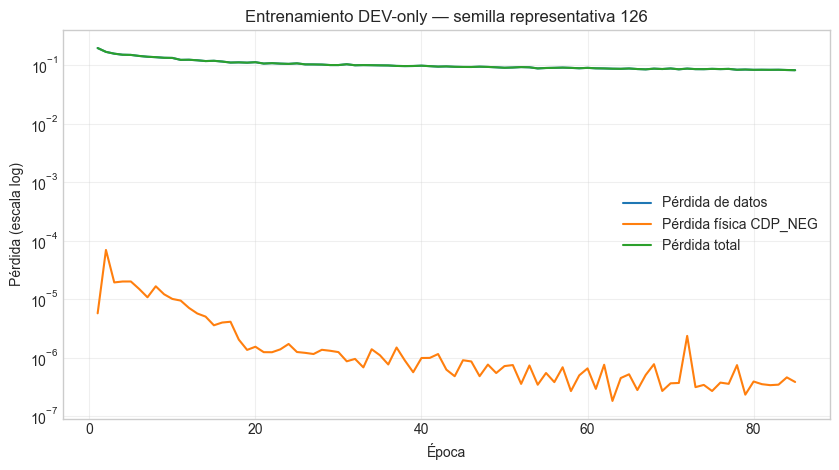

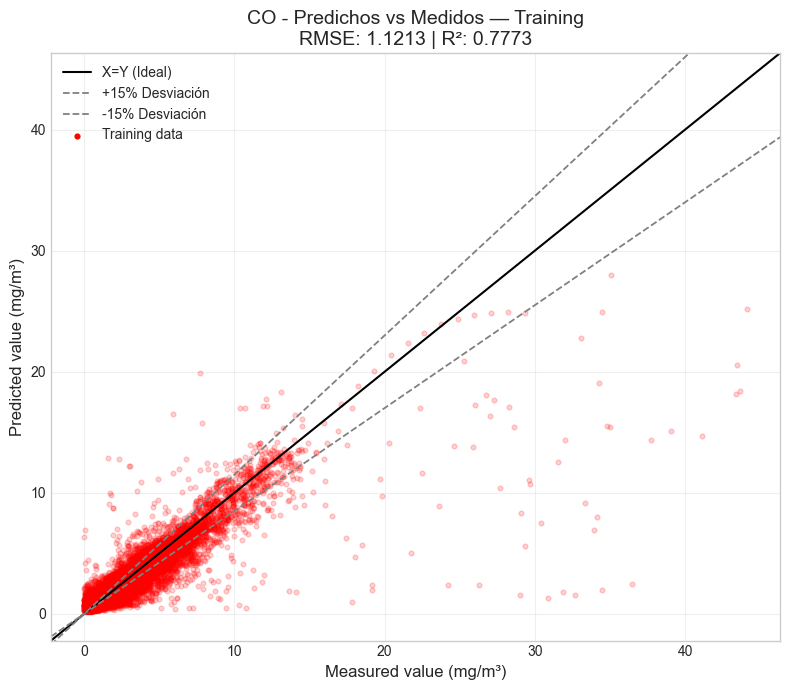

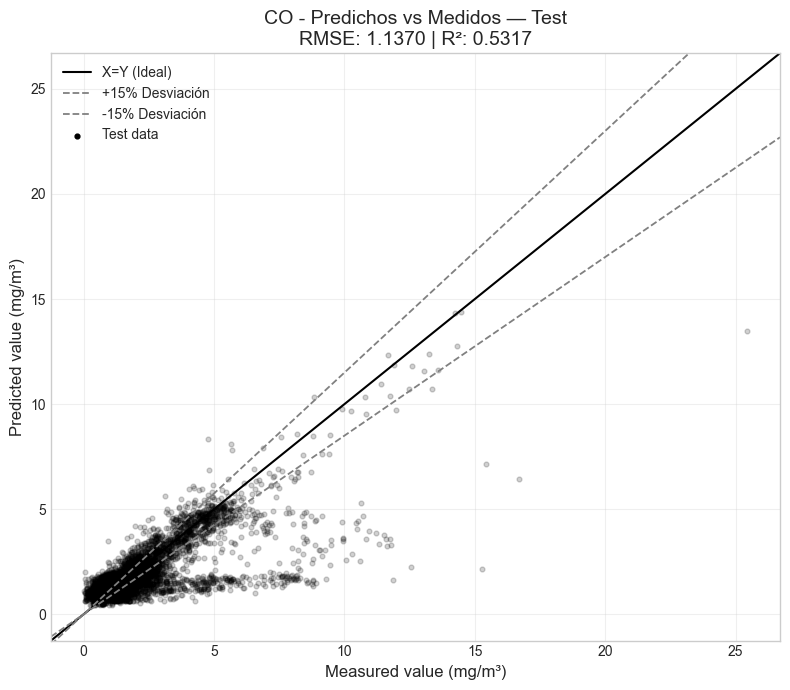

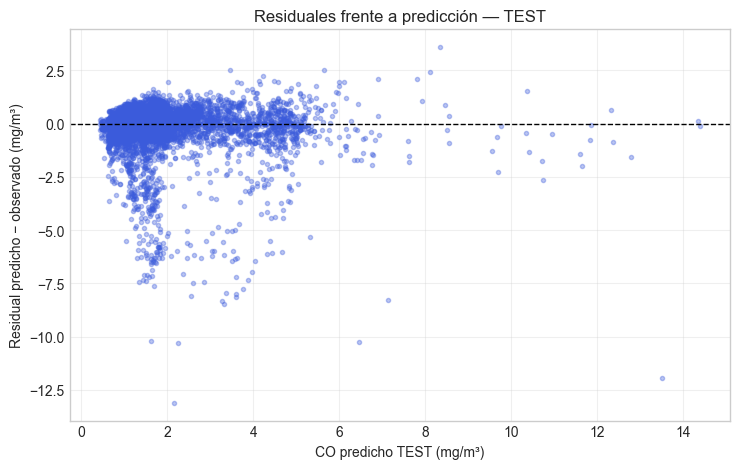

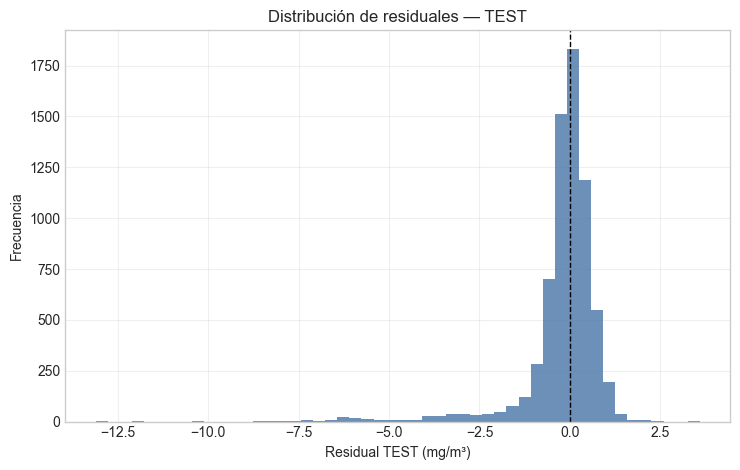

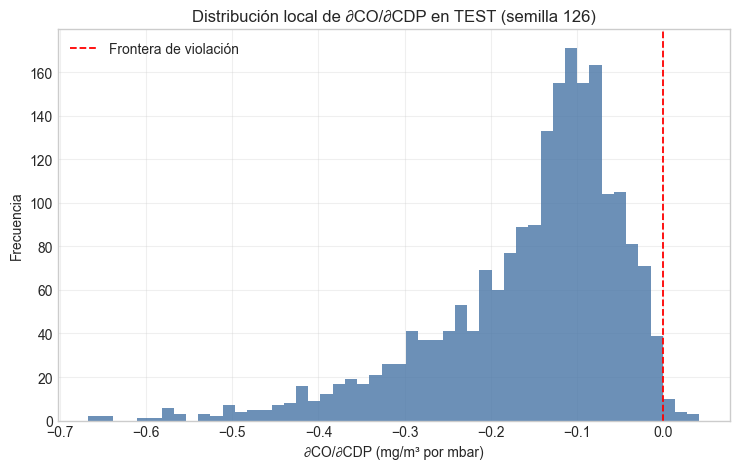

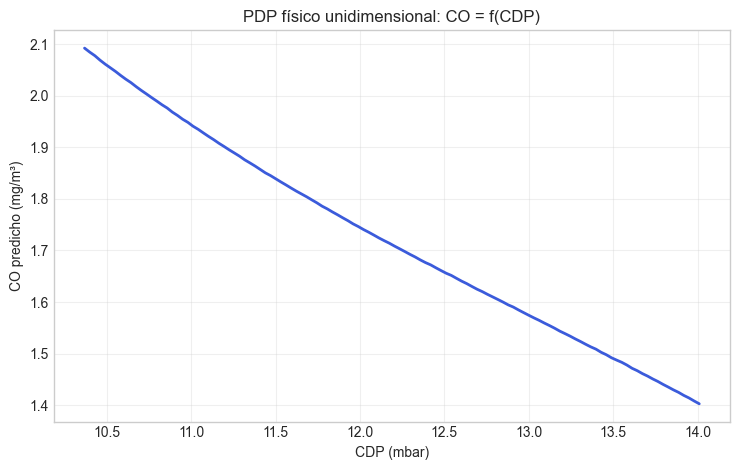

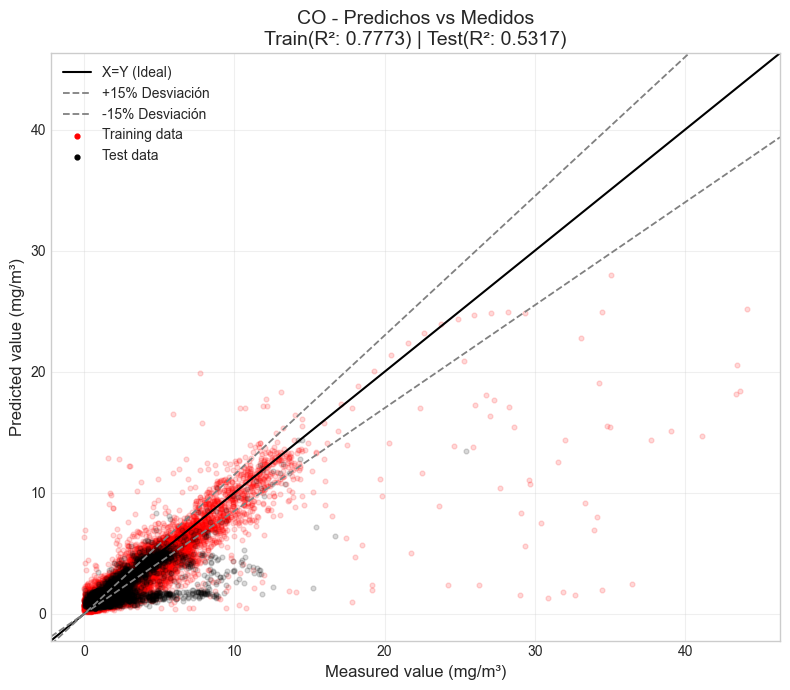

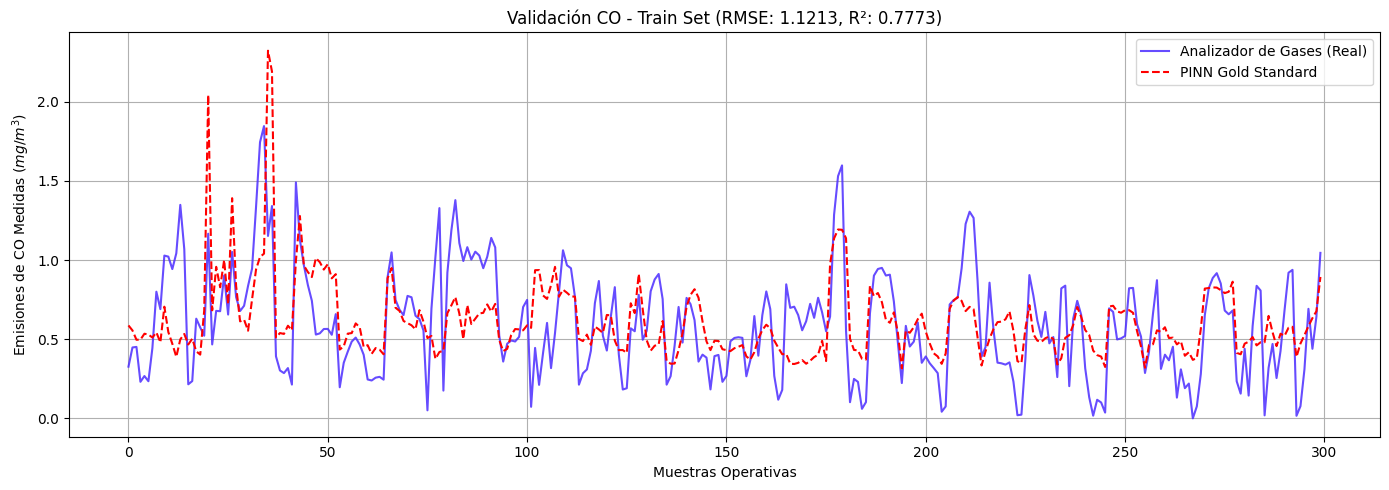

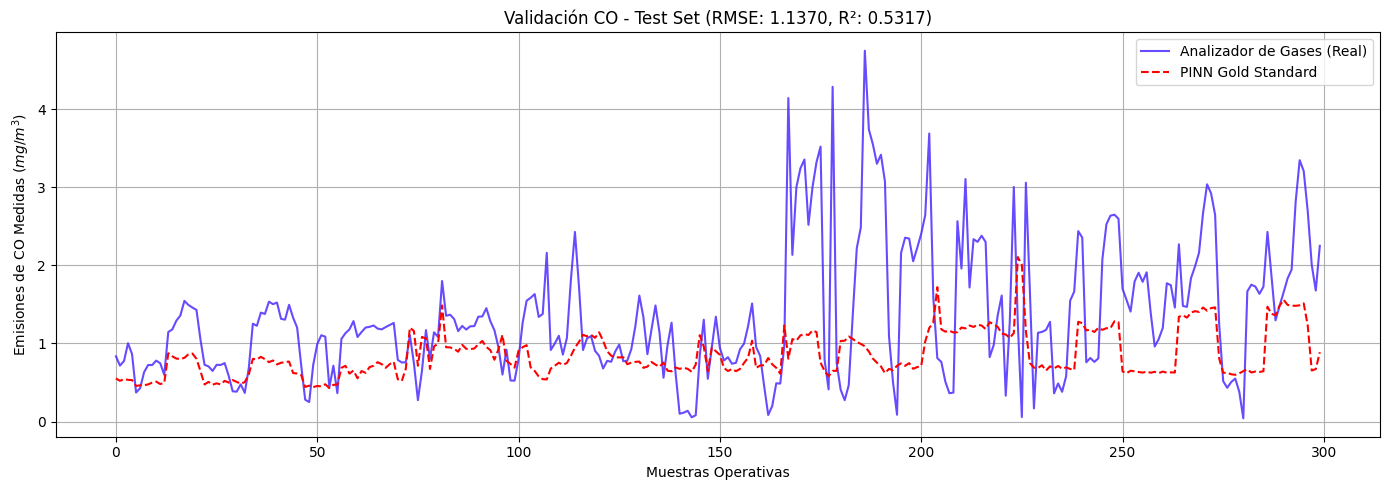

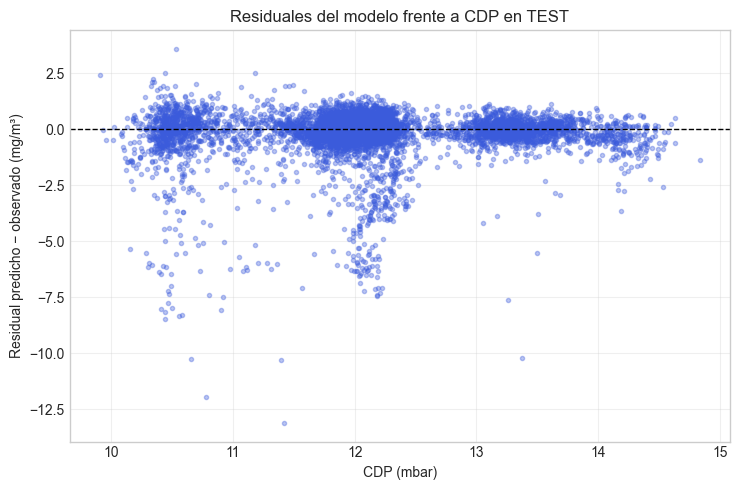

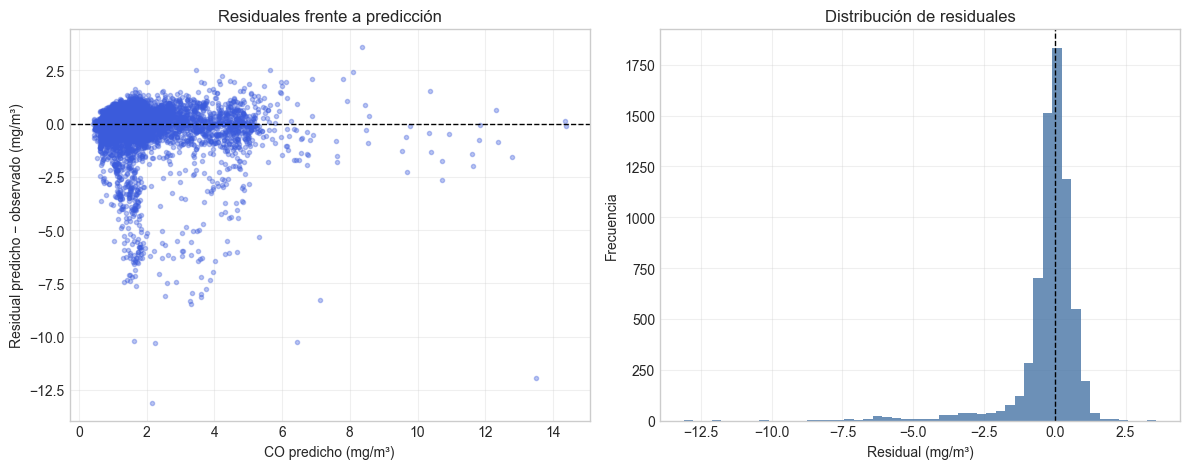

In [17]:
# [C-09.01] Figuras predictivas y físicas FINAL-01 a FINAL-07 y FINAL-09 a FINAL-13
def save_figure(figure: plt.Figure, stem: str) -> None:
    """Persiste cada figura en PNG de alta resolución y SVG vectorial."""
    figure.tight_layout()
    figure.savefig(PATHS.figures / f"{stem}.png", dpi=300, bbox_inches="tight")
    figure.savefig(PATHS.figures / f"{stem}.svg", bbox_inches="tight")
    plt.show()
    plt.close(figure)


plt.style.use("seaborn-v0_8-whitegrid")
DEV_PLOT_METRICS = FINAL_METRICS.loc[FINAL_METRICS.split.eq("DEV")].iloc[0]
TEST_PLOT_METRICS = FINAL_METRICS.loc[FINAL_METRICS.split.eq("TEST")].iloc[0]


def parity_limits(*arrays: np.ndarray) -> tuple[list[float], np.ndarray]:
    finite_values = np.concatenate(
        [np.asarray(values, dtype=float)[np.isfinite(values)] for values in arrays]
    )
    minimum = float(finite_values.min())
    maximum = float(finite_values.max())
    span = max(maximum - minimum, np.finfo(float).eps)
    limits = [minimum - 0.05 * span, maximum + 0.05 * span]
    return limits, np.asarray(limits, dtype=float)


def add_parity_references(axis: plt.Axes, limits: list[float], limits_array: np.ndarray) -> None:
    axis.plot(limits, limits, color="black", linestyle="-", linewidth=1.5, label="X=Y (Ideal)")
    axis.plot(
        limits_array,
        limits_array * 1.15,
        color="gray",
        linestyle="--",
        linewidth=1.3,
        label="+15% Desviación",
    )
    axis.plot(
        limits_array,
        limits_array * 0.85,
        color="gray",
        linestyle="--",
        linewidth=1.3,
        label="-15% Desviación",
    )


def parity_figure(
    observed: np.ndarray,
    predicted: np.ndarray,
    split_label: str,
    metrics: pd.Series,
    stem: str,
    color: str,
) -> None:
    limits, limits_array = parity_limits(observed, predicted)
    figure, axis = plt.subplots(figsize=(8, 7))
    add_parity_references(axis, limits, limits_array)
    axis.scatter(
        observed,
        predicted,
        color=color,
        label=f"{split_label} data",
        s=12,
        alpha=0.18,
    )
    axis.set_xlim(limits)
    axis.set_ylim(limits)
    axis.set_xlabel("Measured value (mg/m³)", fontsize=12)
    axis.set_ylabel("Predicted value (mg/m³)", fontsize=12)
    axis.set_title(
        f"CO - Predichos vs Medidos — {split_label}\n"
        f"RMSE: {float(metrics.RMSE):.4f} | R²: {float(metrics.R2):.4f}",
        fontsize=14,
    )
    legend = axis.legend(loc="upper left", fontsize=10)
    for handle in legend.legend_handles:
        handle.set_alpha(1.0)
    axis.grid(True, alpha=0.3)
    save_figure(figure, stem)


# FINAL-01 — se conserva la historia de entrenamiento exclusiva de R5.
figure, axis = plt.subplots(figsize=(8.5, 4.8))
axis.plot(TRAINING_HISTORY.epoch, TRAINING_HISTORY.loss_data, label="Pérdida de datos")
axis.plot(TRAINING_HISTORY.epoch, TRAINING_HISTORY.loss_physics, label="Pérdida física CDP_NEG")
axis.plot(TRAINING_HISTORY.epoch, TRAINING_HISTORY.loss_total, label="Pérdida total")
axis.set(
    xlabel="Época",
    ylabel="Pérdida (escala log)",
    title=f"Entrenamiento DEV-only — semilla representativa {REPRESENTATIVE_SEED}",
)
axis.set_yscale("log")
axis.legend()
axis.grid(True, alpha=0.3)
save_figure(figure, "FINAL-01_training_history")


# FINAL-02 y FINAL-03 — paridades R5 con el lenguaje visual histórico de R4.
parity_figure(
    y_dev,
    dev_prediction,
    "Training",
    DEV_PLOT_METRICS,
    "FINAL-02_dev_parity",
    "red",
)
parity_figure(
    y_test,
    test_prediction,
    "Test",
    TEST_PLOT_METRICS,
    "FINAL-03_test_parity",
    "black",
)


# FINAL-04 y FINAL-05 — diagnósticos separados propios de R5.
test_residual = test_prediction - y_test
figure, axis = plt.subplots(figsize=(7.5, 4.8))
axis.scatter(test_prediction, test_residual, s=9, alpha=0.35, color="#3b5bdb")
axis.axhline(0, color="black", linestyle="--", linewidth=1)
axis.set(
    xlabel="CO predicho TEST (mg/m³)",
    ylabel="Residual predicho − observado (mg/m³)",
    title="Residuales frente a predicción — TEST",
)
axis.grid(True, alpha=0.3)
save_figure(figure, "FINAL-04_test_residual_vs_predicted")

figure, axis = plt.subplots(figsize=(7.5, 4.8))
axis.hist(test_residual, bins=50, alpha=0.82, color="#4c78a8")
axis.axvline(0, color="black", linestyle="--", linewidth=1)
axis.set(
    xlabel="Residual TEST (mg/m³)",
    ylabel="Frecuencia",
    title="Distribución de residuales — TEST",
)
axis.grid(True, alpha=0.3)
save_figure(figure, "FINAL-05_test_residual_distribution")


# FINAL-06 y FINAL-07 — visualizaciones físicas exclusivas de R5.
figure, axis = plt.subplots(figsize=(7.5, 4.8))
axis.hist(gradient_arrays["TEST"], bins=50, alpha=0.82, color="#4c78a8")
axis.axvline(0, color="red", linestyle="--", linewidth=1.3, label="Frontera de violación")
axis.set(
    xlabel="∂CO/∂CDP (mg/m³ por mbar)",
    ylabel="Frecuencia",
    title=(
        "Distribución local de ∂CO/∂CDP en TEST "
        f"(semilla {REPRESENTATIVE_SEED})"
    ),
)
axis.legend()
axis.grid(True, alpha=0.3)
save_figure(figure, "FINAL-06_physical_gradient_distribution")

dev_median = DEV_DATA[FEATURES].median().to_numpy(float)
cdp_index = FEATURES.index(PHYSICS_FEATURE)
cdp_low, cdp_high = np.quantile(DEV_DATA[PHYSICS_FEATURE], [0.05, 0.95])
cdp_grid = np.linspace(cdp_low, cdp_high, PDP_POINTS)
pdp_inputs = np.tile(dev_median, (PDP_POINTS, 1))
pdp_inputs[:, cdp_index] = cdp_grid
pdp_prediction = predict_physical(
    FINAL_MODEL, pdp_inputs.astype(np.float32), X_SCALER, Y_SCALER, DEVICE
)
PDP_TABLE = pd.DataFrame({"CDP": cdp_grid, "predicted_CO_mg_m3": pdp_prediction})
atomic_csv(PATHS.tables / "PHYSICAL_PDP_CDP_CO_R5F_STD.csv", PDP_TABLE)
figure, axis = plt.subplots(figsize=(7.5, 4.8))
axis.plot(cdp_grid, pdp_prediction, linewidth=2, color="#3b5bdb")
axis.set(
    xlabel="CDP (mbar)",
    ylabel="CO predicho (mg/m³)",
    title="PDP físico unidimensional: CO = f(CDP)",
)
axis.grid(True, alpha=0.3)
save_figure(figure, "FINAL-07_physical_PDP_CDP")


# FINAL-09 — paridad combinada histórica de R4, adaptada al modelo único R5.
combined_limits, combined_array = parity_limits(
    y_dev, dev_prediction, y_test, test_prediction
)
figure, axis = plt.subplots(figsize=(8, 7))
add_parity_references(axis, combined_limits, combined_array)
axis.scatter(
    y_dev,
    dev_prediction,
    color="red",
    label="Training data",
    s=12,
    alpha=0.15,
)
axis.scatter(
    y_test,
    test_prediction,
    color="black",
    label="Test data",
    s=12,
    alpha=0.15,
)
axis.set_xlim(combined_limits)
axis.set_ylim(combined_limits)
axis.set_xlabel("Measured value (mg/m³)", fontsize=12)
axis.set_ylabel("Predicted value (mg/m³)", fontsize=12)
axis.set_title(
    "CO - Predichos vs Medidos\n"
    f"Train(R²: {float(DEV_PLOT_METRICS.R2):.4f}) | "
    f"Test(R²: {float(TEST_PLOT_METRICS.R2):.4f})",
    fontsize=14,
)
legend = axis.legend(loc="upper left", fontsize=10)
for handle in legend.legend_handles:
    handle.set_alpha(1.0)
axis.grid(True, alpha=0.3)
save_figure(figure, "FINAL-09_combined_parity_dev_test")


# FINAL-10 y FINAL-11 — series operativas históricas de R4.
OPERATIONAL_SAMPLE_ROWS = 300


def plot_co_operational_sample(
    y_true: np.ndarray,
    predicted: np.ndarray,
    split_type: str,
    metrics: pd.Series,
    stem: str,
) -> None:
    sample_rows = min(OPERATIONAL_SAMPLE_ROWS, len(y_true), len(predicted))
    with plt.style.context("default"):
        figure, axis = plt.subplots(figsize=(14, 5))
        axis.plot(
            y_true[:sample_rows],
            label="Analizador de Gases (Real)",
            color="#4b2cff",
            alpha=0.85,
        )
        axis.plot(
            predicted[:sample_rows],
            label="PINN Gold Standard",
            color="red",
            linestyle="--",
            linewidth=1.5,
        )
        axis.set_title(
            f"Validación CO - {split_type} "
            f"(RMSE: {float(metrics.RMSE):.4f}, R²: {float(metrics.R2):.4f})"
        )
        axis.set_ylabel(r"Emisiones de CO Medidas ($mg/m^3$)")
        axis.set_xlabel("Muestras Operativas")
        axis.legend()
        axis.grid(True)
        save_figure(figure, stem)


plot_co_operational_sample(
    y_dev,
    dev_prediction,
    "Train Set",
    DEV_PLOT_METRICS,
    "FINAL-10_dev_operational_series",
)
plot_co_operational_sample(
    y_test,
    test_prediction,
    "Test Set",
    TEST_PLOT_METRICS,
    "FINAL-11_test_operational_series",
)


# FINAL-12 — residual frente a CDP recuperado de R4.
figure, axis = plt.subplots(figsize=(7.5, 5.0))
axis.scatter(TEST_PREDICTIONS["CDP"], test_residual, s=9, alpha=0.35, color="#3b5bdb")
axis.axhline(0, linestyle="--", color="black", linewidth=1)
axis.set(
    title="Residuales del modelo frente a CDP en TEST",
    xlabel="CDP (mbar)",
    ylabel="Residual predicho − observado (mg/m³)",
)
axis.grid(True, alpha=0.3)
save_figure(figure, "FINAL-12_test_residual_vs_CDP")


# FINAL-13 — panel residual combinado de R4, sin eliminar FINAL-04 y FINAL-05.
figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(test_prediction, test_residual, s=9, alpha=0.35, color="#3b5bdb")
axes[0].axhline(0, linestyle="--", color="black", linewidth=1)
axes[0].set(
    title="Residuales frente a predicción",
    xlabel="CO predicho (mg/m³)",
    ylabel="Residual predicho − observado (mg/m³)",
)
axes[1].hist(test_residual, bins=50, alpha=0.82, color="#4c78a8")
axes[1].axvline(0, linestyle="--", color="black", linewidth=1)
axes[1].set(
    title="Distribución de residuales",
    xlabel="Residual (mg/m³)",
    ylabel="Frecuencia",
)
for axis in axes:
    axis.grid(True, alpha=0.3)
save_figure(figure, "FINAL-13_test_residual_diagnostics")


### C-09.02 — Perfil computacional y figura FINAL-08

**Objetivo:** caracterizar tamaño, parámetros, latencia y throughput del artefacto desplegable.  
**Nota:** estas mediciones describen el hardware actual; no sustituyen una comparación oficial con XGBoost.


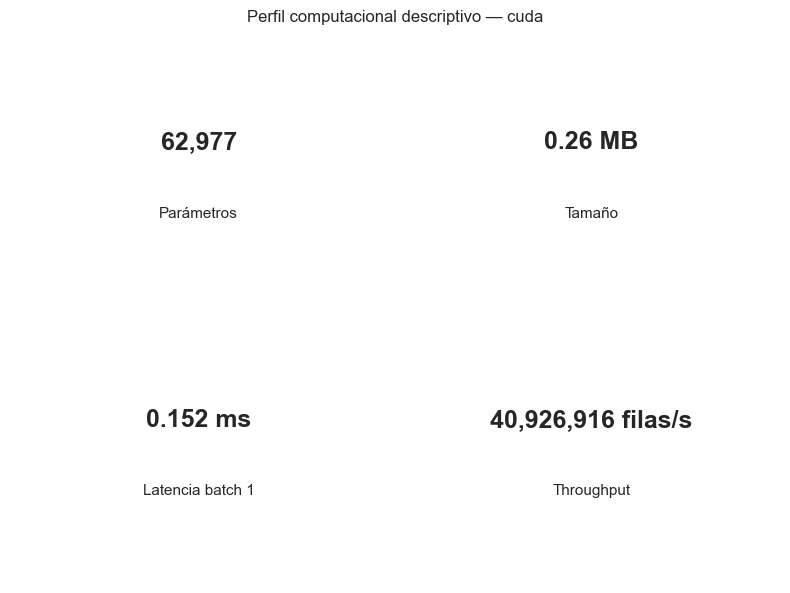

,device,cpu,gpu,ram_gib,trainable_parameters,MACs_per_inference,FLOPs_approx,serialized_size_bytes,serialized_size_MB,latency_batch1_median_ms,latency_batch1_p95_ms,throughput_rows_s,training_time_s
0,cuda,"Intel64 Family 6 Model 183 Stepping 1, Genuine...",NVIDIA GeForce RTX 5070 Ti,31.746,62977,62304,124608,261215,0.261215,0.152,0.494805,4.092692e+07,11.553246


In [18]:
# [C-09.02] Huella computacional normalizada
def synchronize(device: torch.device) -> None:
    if device.type == "cuda":
        torch.cuda.synchronize(device)


def benchmark_latency(
    model: nn.Module,
    standardized_row: np.ndarray,
    device: torch.device,
) -> dict:
    tensor = torch.from_numpy(standardized_row.astype(np.float32)).to(device)
    with torch.no_grad():
        for _ in range(LATENCY_WARMUP):
            model(tensor)
        synchronize(device)
        samples = []
        for _ in range(LATENCY_REPETITIONS):
            synchronize(device)
            started = time.perf_counter()
            model(tensor)
            synchronize(device)
            samples.append((time.perf_counter() - started) * 1000.0)
    return {
        "latency_batch1_median_ms": float(np.median(samples)),
        "latency_batch1_p95_ms": float(np.quantile(samples, 0.95)),
    }


def benchmark_throughput(
    model: nn.Module,
    standardized_values: np.ndarray,
    device: torch.device,
) -> float:
    tensor = torch.from_numpy(standardized_values.astype(np.float32)).to(device)
    with torch.no_grad():
        for _ in range(THROUGHPUT_WARMUP):
            model(tensor)
        synchronize(device)
        durations = []
        for _ in range(THROUGHPUT_REPETITIONS):
            synchronize(device)
            started = time.perf_counter()
            model(tensor)
            synchronize(device)
            durations.append(time.perf_counter() - started)
    return float(len(tensor) / np.median(durations))


latency = benchmark_latency(
    FINAL_MODEL,
    X_SCALER.transform(x_test[:1]),
    DEVICE,
)
throughput = benchmark_throughput(
    FINAL_MODEL,
    X_SCALER.transform(x_test),
    DEVICE,
)
architecture = architecture_summary(FINAL_MODEL, BEST_CONFIG)
model_bytes = MODEL_PATH.stat().st_size
RESOURCE_PROFILE = pd.DataFrame(
    [
        {
            "device": str(DEVICE),
            "cpu": platform.processor() or platform.machine(),
            "gpu": ENVIRONMENT.get("gpu_name"),
            "ram_gib": ENVIRONMENT["ram_gib"],
            "trainable_parameters": architecture["trainable_parameters"],
            "MACs_per_inference": architecture["MACs_per_inference"],
            "FLOPs_approx": architecture["FLOPs_approx"],
            "serialized_size_bytes": model_bytes,
            "serialized_size_MB": model_bytes / 1_000_000,
            **latency,
            "throughput_rows_s": throughput,
            "training_time_s": float(TRAINING_SUMMARY.iloc[0].training_time_s),
        }
    ]
)
atomic_csv(PATHS.tables / "RESOURCE_PROFILE_CO_R5F_STD.csv", RESOURCE_PROFILE)

dev_metrics = FINAL_METRICS.loc[FINAL_METRICS.split.eq("DEV")].iloc[0]
test_metrics = FINAL_METRICS.loc[FINAL_METRICS.split.eq("TEST")].iloc[0]
dev_physics = PHYSICS_AUDIT.loc[PHYSICS_AUDIT.split.eq("DEV")].iloc[0]
test_physics = PHYSICS_AUDIT.loc[PHYSICS_AUDIT.split.eq("TEST")].iloc[0]
MODEL_PROFILE = {
    "version": VERSION,
    "status": "EVALUATED_ONCE_ON_FROZEN_TEST",
    "generated_at_utc": utc_now(),
    "framework": "PyTorch",
    "framework_version": torch.__version__,
    "dtype": "float32",
    "device": str(DEVICE),
    "cpu": RESOURCE_PROFILE.iloc[0].cpu,
    "gpu": RESOURCE_PROFILE.iloc[0].gpu,
    "ram_gib": float(RESOURCE_PROFILE.iloc[0].ram_gib),
    "trainable_parameters": int(architecture["trainable_parameters"]),
    "serialized_size_bytes": model_bytes,
    "serialized_size_MB": model_bytes / 1_000_000,
    "latency_batch1_median_ms": latency["latency_batch1_median_ms"],
    "latency_batch1_p95_ms": latency["latency_batch1_p95_ms"],
    "throughput_rows_s": throughput,
    "representative_seed": REPRESENTATIVE_SEED,
    "final_epochs": FINAL_EPOCHS,
    "use_lbfgs": USE_LBFGS,
    "R2_DEV": float(dev_metrics.R2),
    "R2_TEST": float(test_metrics.R2),
    "RMSE_DEV": float(dev_metrics.RMSE),
    "RMSE_TEST": float(test_metrics.RMSE),
    "MAE_DEV": float(dev_metrics.MAE),
    "MAE_TEST": float(test_metrics.MAE),
    "NRMSE_MEAN_TEST_pct": float(test_metrics.NRMSE_mean_pct),
    "PCD_DEV_pct": float(dev_physics.PCD_pct),
    "PCD_TEST_pct": float(test_physics.PCD_pct),
    "test_physics_status": TEST_PHYSICS_STATUS,
    "physics_mode": PHYSICS_MODE,
    "model_sha256": sha256_file(MODEL_PATH),
}
atomic_json(
    PATHS.configs / "MODEL_PROFILE_CO_PINN_INTERP_R5.json",
    MODEL_PROFILE,
)

figure, axes = plt.subplots(2, 2, figsize=(8, 6))
kpis = [
    ("Parámetros", f"{architecture['trainable_parameters']:,}"),
    ("Tamaño", f"{model_bytes / 1_000_000:.2f} MB"),
    ("Latencia batch 1", f"{latency['latency_batch1_median_ms']:.3f} ms"),
    ("Throughput", f"{throughput:,.0f} filas/s"),
]
for axis, (label, value) in zip(axes.ravel(), kpis):
    axis.axis("off")
    axis.text(0.5, 0.62, value, ha="center", va="center", fontsize=18, weight="bold")
    axis.text(0.5, 0.35, label, ha="center", va="center", fontsize=11)
figure.suptitle(f"Perfil computacional descriptivo — {DEVICE}")
save_figure(figure, "FINAL-08_computational_profile")
display(RESOURCE_PROFILE)


## SEC-10 — Persistencia, manifiesto y cierre

### C-10.01 — Copia trazable de entradas y reporte técnico

**Objetivo:** preservar junto al modelo las decisiones FROZEN consumidas y una interpretación académica de los resultados.  
**Control:** las copias deben conservar los hashes upstream.


In [19]:
# [C-10.01] Copia trazable de configuración y reporte técnico
copy_map = {
    "BEST_CONFIG_CO_INTERP_R5.json": FROZEN["artifact_paths"]["best_config"],
    "FINAL_TRAINING_POLICY_CO_INTERP_R5.json": FROZEN["artifact_paths"]["training_policy"],
    "FINAL_REPRESENTATIVE_SEED_CO_R5.json": FROZEN["artifact_paths"]["representative_seed"],
    "FROZEN_CONFIG_MANIFEST_CO_INTERP_R5.json": FROZEN["artifact_paths"]["frozen_opt"],
}
for name, source in copy_map.items():
    destination = PATHS.configs / name
    shutil.copy2(source, destination)
    if sha256_file(source) != sha256_file(destination):
        raise RuntimeError(f"La copia no conserva el hash: {name}")

test_metric_row = FINAL_METRICS.loc[FINAL_METRICS.split.eq("TEST")].iloc[0]
test_physics_row = PHYSICS_AUDIT.loc[PHYSICS_AUDIT.split.eq("TEST")].iloc[0]
report = f"""# Informe técnico — CO interpolativo FINAL R5F_STD

## Contrato

El notebook consumió la configuración `{BEST_CONFIG['config_hash']}` del trial
{BEST_CONFIG['provenance_trial_number']}, la seed representativa
{REPRESENTATIVE_SEED}, {FINAL_EPOCHS} épocas y `USE_LBFGS={USE_LBFGS}`. Todas las
decisiones se congelaron con DEV antes de abrir TEST.

## Resultado TEST

- R²: {test_metric_row.R2:.6f}
- RMSE: {test_metric_row.RMSE:.6f} mg/m³
- MAE: {test_metric_row.MAE:.6f} mg/m³
- NRMSE_mean: {test_metric_row.NRMSE_mean_pct:.3f} %
- PCD CDP_NEG: {test_physics_row.PCD_pct:.3f} %
- Estado físico: {TEST_PHYSICS_STATUS}

`NRMSE_mean` no representa Relative Accuracy, RATA ni PS-16. TEST fue abierto una
sola vez y no produjo reentrenamiento, sustitución de candidato ni ajuste de seed,
épocas, lambda o física.
"""
atomic_text(
    PATHS.reports / "FINAL_TECHNICAL_REPORT_CO_R5F_STD.md",
    report,
)


### C-10.02 — Manifiesto final y hashes de artefactos

**Objetivo:** cerrar una cadena auditable PROTOCOL → OPT → FINAL → TEST.  
**Criterio COMPLETE:** modelo único congelado, apertura TEST única, artefactos obligatorios presentes y ausencia de reajuste post-TEST.


In [20]:
# [C-10.02] Manifiesto final y hashes de artefactos
required_outputs = [
    MODEL_PATH,
    PATHS.configs / "MODEL_PROFILE_CO_PINN_INTERP_R5.json",
    PATHS.tables / "DEV_PREDICTIONS_CO_R5F_STD.csv",
    PATHS.tables / "TEST_PREDICTIONS_CO_R5F_STD.csv",
    PATHS.tables / "FINAL_METRICS_CO_R5F_STD.csv",
    PATHS.tables / "PHYSICS_AUDIT_CO_R5F_STD.csv",
    PATHS.tables / "RESOURCE_PROFILE_CO_R5F_STD.csv",
    PATHS.audit / "HANDOFF_HASH_CHECK_CO_R5F_STD.csv",
    PATHS.audit / "TEST_ACCESS_AUDIT_CO_R5F_STD.json",
    PATHS.audit / "MODEL_RELOAD_EQUIVALENCE_CO_R5F_STD.json",
    PATHS.reports / "FINAL_TECHNICAL_REPORT_CO_R5F_STD.md",
]
figure_specs = [
    (1, "training_history"),
    (2, "dev_parity"),
    (3, "test_parity"),
    (4, "test_residual_vs_predicted"),
    (5, "test_residual_distribution"),
    (6, "physical_gradient_distribution"),
    (7, "physical_PDP_CDP"),
    (8, "computational_profile"),
    (9, "combined_parity_dev_test"),
    (10, "dev_operational_series"),
    (11, "test_operational_series"),
    (12, "test_residual_vs_CDP"),
    (13, "test_residual_diagnostics"),
]
required_outputs.extend(
    PATHS.figures / f"FINAL-{number:02d}_{suffix}.{extension}"
    for number, suffix in figure_specs
    for extension in ("png", "svg")
)
missing_outputs = [str(path) for path in required_outputs if not path.is_file()]
if missing_outputs:
    raise FileNotFoundError("Entregables finales ausentes:\n- " + "\n- ".join(missing_outputs))

excluded_names = {
    "ARTIFACT_HASHES_CO_R5F_STD.csv",
    "FINAL_MODEL_MANIFEST_CO_R5F_STD.json",
}
artifact_paths = [
    path
    for path in sorted(PATHS.work.rglob("*"))
    if path.is_file() and path.name not in excluded_names
]
ARTIFACT_HASHES = pd.DataFrame(
    [
        {
            "path": str(path.relative_to(PATHS.work)),
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
        for path in artifact_paths
    ]
)
atomic_csv(PATHS.audit / "ARTIFACT_HASHES_CO_R5F_STD.csv", ARTIFACT_HASHES)

FINAL_MANIFEST = {
    "status": "COMPLETE",
    "version": VERSION,
    "generated_at_utc": utc_now(),
    "producer_notebook": CURRENT_NOTEBOOK_NAME,
    "protocol_version": PROTOCOL_VERSION,
    "opt_version": OPT_VERSION,
    "input_contract": "PROTOCOL_R1_AND_CO_OPT_R5_FROZEN_ONLY",
    "config_hash": BEST_CONFIG["config_hash"],
    "provenance_trial_number": BEST_CONFIG["provenance_trial_number"],
    "row_assignment_sha256": FROZEN["assignment_hash"],
    "fold_assignment_sha256": FROZEN["fold_hash"],
    "representative_seed": REPRESENTATIVE_SEED,
    "final_epochs": FINAL_EPOCHS,
    "use_lbfgs": USE_LBFGS,
    "model_count": 1,
    "model_sha256": sha256_file(MODEL_PATH),
    "pre_test_gate_sha256": PRE_TEST_GATE["gate_sha256"],
    "test_opened_once": TEST_ACCESS_AUDIT["opened_once"],
    "test_access_count": TEST_ACCESS_AUDIT["access_count"],
    "test_rows": len(TEST_DATA),
    "test_physics_status": TEST_PHYSICS_STATUS,
    "model_changed_after_test": False,
    "retraining_after_test": False,
    "artifact_hash_table": "audit/ARTIFACT_HASHES_CO_R5F_STD.csv",
}
if not (
    FINAL_MANIFEST["test_opened_once"]
    and FINAL_MANIFEST["test_access_count"] == 1
    and FINAL_MANIFEST["model_count"] == 1
    and not FINAL_MANIFEST["retraining_after_test"]
):
    raise RuntimeError("No se puede declarar COMPLETE")
atomic_json(
    PATHS.configs / "FINAL_MODEL_MANIFEST_CO_R5F_STD.json",
    FINAL_MANIFEST,
)
display(pd.Series(FINAL_MANIFEST, name="resultado").to_frame())
print(f"FINAL COMPLETO: {PATHS.work}")


,resultado
status,COMPLETE
version,CO_INTERP_FINAL_R5F_STD
generated_at_utc,2026-08-26T05:52:14.563419+00:00
producer_notebook,04_Gold_Standard_PINN_CO_INTERP_FINAL - R5F_ST...
protocol_version,INTERP_PROTOCOL_R1
opt_version,CO_INTERP_OPT_R5
input_contract,PROTOCOL_R1_AND_CO_OPT_R5_FROZEN_ONLY
config_hash,e5d4ddb830ce31387f933b4c4522485991650de24af4ae...
provenance_trial_number,89
row_assignment_sha256,1a1706f37198468e010c066361444072daddf979543bd4...


FINAL COMPLETO: C:\ChatGPT-Work\Walk_Forward R8\models\interp\work_pinn_co_interp_final_r5f_std


## Resumen ejecutivo

Al completar `Run all`, este notebook deja un único modelo PINN de CO entrenado con todo DEV y la seed representativa congelada por OPT R5. El artefacto se serializa, se recarga y se firma antes de materializar TEST. La evaluación final reporta precisión, residuales, física `CDP_NEG` y costo computacional, sin usar TEST para modificar ninguna decisión.

Artefactos principales:

- `model/final_model_seed_126.pt`;
- `configs/MODEL_PROFILE_CO_PINN_INTERP_R5.json`;
- `configs/FINAL_MODEL_MANIFEST_CO_R5F_STD.json`;
- predicciones y métricas DEV/TEST;
- auditorías de handoff, recarga y acceso a TEST;
- figuras `FINAL-01` a `FINAL-13` en PNG y SVG;
- reporte técnico y hashes.

El catálogo visual conserva las ocho figuras originales de R5 e incorpora las vistas históricas aplicables de R4: paridad combinada DEV/TEST, series operativas DEV y TEST, residuales frente a CDP y diagnóstico residual combinado. No se genera un panel multisemilla artificial porque el contrato científico R5F_STD especifica un único modelo representativo.


## Registro de versión

| Versión | Cambio | Clasificación |
|---|---|---|
| R5F_STD | Creación del FINAL para consumir CO INTERP OPT R5 | funcional |
| R5F_STD | Modelo único con seed representativa 126, no ensamble | científico congelado |
| R5F_STD | `FINAL_EPOCHS=85`, `CDP_NEG`, `USE_LBFGS=False` leídos del handoff | científico congelado |
| R5F_STD | Verificación de hashes, puerta pre-TEST y auditoría de apertura única | control metodológico |
| R5F_STD | Portabilidad local/Colab mediante raíz explícita o variable de entorno | funcional |
| R5F_STD | Consolidación visual R4 + R5: 13 figuras en PNG/SVG y estilo histórico homogéneo | documental/visual |

**TEST no se abre al crear o validar estáticamente este notebook. Solo se materializa al ejecutar SEC-07 después de entrenar y congelar el modelo.**
